# Spacetime Resonance Topography

## Imports and Helpers

In [1]:
# imports
import numpy as np
import pandas as pd
import seaborn as sns
import hdim_opt as hdim
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import warnings
import random
from sklearn.decomposition import PCA
from scipy.interpolate import griddata
from numpy.fft import fft2, fftshift, fftfreq
from scipy.stats import differential_entropy
from scipy.signal import find_peaks
from joblib import Parallel, delayed
from tqdm import tqdm
sns.set_style('dark')
sns.set_context("paper", font_scale=1.2, rc={
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "figure.titlesize": 18,
    "xtick.labelsize": 12.5,
    "ytick.labelsize": 12.5
})
plot_resolution = 'high'
history_path = 'spacetime_histories.csv'

### physical constants
epsilon = np.finfo(float).tiny
hbar = 1.0545718e-34 # hbar (SI)
C_SI = 299792458.0 # speed of light (m/s)
G_SI = 6.67430e-11 # gravitational constant (SI)
kappa_si = (8.0 * np.pi * G_SI) / (C_SI**4) # einstein coupling constant
t_planck = 5.391e-44 # planck time (SI)
l_planck = 1.616e-35 # planck length (SI)
m_planck = 2.176e-8 # kg
H_max = 1/t_planck # max expansion 1/s
rho_planck = 1e113 # planck energy limit
zeta_order = ['t','a','adot','adoubledot','phi','phidot','phidoubledot','mass_phi','k','beta','gamma']
zeta_order_si = ['t_si','a_si','adot_si','adoubledot_si','phi_si','phidot_si','phidoubledot_si','mass_si','k','beta','gamma']
plot_label_map = {'t': r'$t$', 'a': r'$a$', 'adot': r'$\dot{a}$', 'adoubledot': r'$\ddot{a}$', 
                  'phi': r'$\phi$', 'phidot': r'$\dot{\phi}$', 'phidoubledot': r'$\ddot{\phi}$', 'mass_phi': r'$m_{\phi}$', 
                  'k': r'$k$', 'beta': r'$\beta$', 'gamma': r'$\gamma$'
    }
formatted_labels = [plot_label_map.get(name, name) for name in zeta_order]


#### parameter space bounds #####

### physical constant exponents
log_tp = np.log10(t_planck)          # ~ -43.3 (Planck time)
log_lp = np.log10(l_planck)          # ~ -34.8 (Planck length)
log_mp = np.log10(m_planck)          # ~ -7.7  (Planck mass)
log_th = 18.0                        # ~ hubble age (seconds)
log_lh = 27.0                        # ~ Hubble Scale (meters)
log_mh = np.log10(hbar / (C_SI * 10**log_lh)) # ~ -69.0 (Compton/Hubble mass)

# derived first-order floors (velocity/flux): smallest length over largest time
log_v_floor = log_lp - log_th        # -34.8 - 18 = -52.8 (metric/field velocity floor)
log_v_ceil  = log_lh - log_tp        # 27.0 - (-43.3) = 70.3 (metric velocity ceiling)
log_phi_v_ceil = 65.0                # 65 for field flux to respect Planck energy limits (10^113)

# derived second-order floors (acceleration/dynamics): smallest velocity change over largest time
log_acc_floor = log_v_floor - log_th   # -52.8 - 18 = -70.8 (Acceleration Floor)
log_acc_ceil  = 113.0                  # Planck Acceleration limit

# scalar potential: field amplitude required to hit 10^-120 density at m_hubble
log_phi_floor = -34.0                # derived from rho_vac / m_hubble
log_phi_ceil  = 22.0                 # Planck energy field limit 10^113 rho_vac / m_planck

# ### strictly positive parameters
bounds_t    = (log_tp, log_th)       # s: Planck time to Hubble age
bounds_a    = (log_lp, log_lh)       # m: Planck length to Hubble scale
bounds_mass = (log_mh, log_mp)       # kg: compton mass to planck mass 

### symmetric parameters (range = |ceiling - floor|)
# kinematics
bounds_adot       = (-(log_v_ceil - log_v_floor), (log_v_ceil - log_v_floor)) # m/s: ceiling 70, floor -52 -> range = 122
bounds_adoubledot = (-(log_acc_ceil - log_acc_floor), (log_acc_ceil - log_acc_floor)) # m/s^2: ceiling 113, Floor -70 -> range = 183

# field dynamics
bounds_phi          = (-(log_phi_ceil - log_phi_floor), (log_phi_ceil - log_phi_floor)) # sqrt(J/m): ceiling 22, floor -34 -> range = 56
bounds_phidot       = (-(log_phi_v_ceil - log_v_floor), (log_phi_v_ceil - log_v_floor))  # sqrt(J/m)/s: ceiling 65, floor -52 -> range = 117
bounds_phidoubledot = (-(108.0 - log_acc_floor), (108.0 - log_acc_floor)) # sqrt(J/m)/s^2: Cciling 108, floor -70 -> range = 178

# linear bounds
bounds_k = (-1.0, 1.0)   # unitless curvature
bounds_beta = (-1.0, 1.0)   # kinetic polarity
bounds_gamma = (-1.0, 1.0)   # vacuum polarity

### define bounds
bounds = [bounds_t, bounds_a, bounds_adot, bounds_adoubledot,
          bounds_phi, bounds_phidot, bounds_phidoubledot, bounds_mass, bounds_k, 
          bounds_beta, bounds_gamma]
n_dim = len(bounds)

### define span for objective function 
lower_bounds = np.array([b[0] for b in bounds])
upper_bounds = np.array([b[1] for b in bounds])
span = upper_bounds - lower_bounds
buffer = hbar/2 * span

## Analysis Functions

In [2]:
def physical_statistics(ensemble_exponents):
    '''
    Main statistical analysis of ensemble.
    '''

    ##### preprocess #####
    df = analyze_coordinate(ensemble_exponents)
    df['probability'] = np.exp(df['probability'])
    total_count = len(df)

    # regime stats for plot annotation
    regime_stats = {'intensity': {}, 'probability': {}}
    for metric in ['intensity', 'probability']:
        temp_map = {}
        for reg in df['regime'].unique():
            r_mask = (df['regime'] == reg)
            r_count = np.sum(r_mask)
            if r_count > 0:
                r_typical = df.loc[r_mask, metric].median() # median value
                temp_map[reg] = r_typical * r_count
        
        # normalize to 100%
        total = sum(temp_map.values())
        regime_stats[metric] = {k: (v / total) * 100 for k, v in temp_map.items()}
    
    ##### plot distributions #####
    
    ### plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 12.5))
    plot_configs = [
        (0, 0, 'beta', 'intensity',   r'Resonance'),
        (0, 1, 'beta', 'probability', r'Probability'),
        (1, 0, 'gamma', 'intensity',  r'Resonance'),
        (1, 1, 'gamma', 'probability', r'Probability')
    ]
    palette = {
        'Canonical': 'cornflowerblue',
        'Phantom': 'crimson',
        'Hybrid': 'orange'
    }

    # iterate through plot configs
    df.rename(columns={'regime':'Regime'},inplace=True)
    for row, col, var, w_col, title_prefix in plot_configs:
        ax = axes[row, col]

        sns.kdeplot(data=df, x=var, weights=df[w_col], hue='Regime', ax=ax, fill=True,
                    alpha=0.6, palette=palette, linewidth=2,
                    common_norm=False, cut=10, gridsize=1000)
        
        label_fancy = r'Kinetic Polarity $\beta$' if var == 'beta' else r'Vacuum Polarity $\gamma$'
        title_fancy = r'Kinetic' if var == 'beta' else r'Vacuum'
        ax.set_xlim(-1.33,1.33)
        ax.set_title(f'{title_prefix} ({title_fancy})', fontweight='bold')
        ax.set_xlabel(label_fancy,fontweight='bold')
        if w_col == 'intensity':
            ylabel = 'Intensity'
        else:
            ylabel = 'Density'
        ax.set_ylabel(ylabel, fontweight='bold')
        # ax.legend(fontsize=13)

    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/phase_comparison.png')
    plt.show()

    
    ##### display statistics #####
    # calculate species resonance and probability, for table
    unique_bodies = np.unique(df['species'])
    stats_list = []
    for body in unique_bodies:
        mask = (df['species'] == body)
        count = np.sum(mask)
        if count > 0:
            # Robust logic: Typical Weight * Population
            median_resonance = df.loc[mask, 'intensity'].median()
            resonance_proportion = median_resonance * count

            median_probability = df.loc[mask, 'probability'].median()
            probability_proportion = median_probability * count
            
            stats_list.append({
                'Species': body,
                'Resonance %': resonance_proportion,
                'Probability %': probability_proportion,
            })

    # create dataframe for table
    res_df = pd.DataFrame(stats_list)
    total_resonance = res_df['Resonance %'].sum()
    res_df['Resonance %'] = (res_df['Resonance %'] / total_resonance) * 100
    total_prob = res_df['Probability %'].sum()
    res_df['Probability %'] = (res_df['Probability %'] / total_prob) * 100
    res_df.sort_values(by='Probability %', ascending=False, inplace=True)
    
    print(f"\n- Topography Analysis")
    print(f"{'Species':<25} | {'Resonance %':<12} | {'Probability %':<12}")
    print("-" * 75)
    for _, row in res_df.iterrows():
        print(f"{row['Species']:<25} | {row['Resonance %']:<12.4f}% | {row['Probability %']:<12.4f}%")

    ##### latex table generation #####
    res_latex = res_df.to_latex(
        index=False,
        caption='Species and Regimes',
        label="tab:species_and_regimes",
        column_format='lrrr',
        float_format="%.4f"
    )

    stats_cols = ['t_si','a_si','adot_si','adoubledot_si','phi_si','phidot_si','phidoubledot_si','mass_si',
                  'k','beta','gamma','rho_kinetic','rho_potential','ricci_si','omega','H','compactness','nec']
    stats_df = df[stats_cols].copy()
    stats_df = stats_df.describe().loc[['50%','mean','std','min','max']].T
    stats_df.rename(columns={'50%':'Median','mean':'Mean','std':'Stdev.','min':'Min.','max':'Max.'},inplace=True)
    stats_df.index = list(plot_label_map.values()) + [r'$\rho_\text{k}$',r'$\rho_\text{v}$','$R$',r'$\omega$','$H$','$C$','NEC']
    
    stats_latex = stats_df.to_latex(
        index=True,
        caption='Ensemble Physical Statistics',
        label="tab:physical_statistics",
        column_format='lr|rr|rr',
        float_format="%.2e"
    )
    print()
    print(stats_latex)

    return res_df, stats_df

def diversity_statistics(ensemble_exponents):
    '''Quantify diversity of the ensemble.'''
    N = len(ensemble_exponents)

    ### normalized standard deviation (occupancy)
    dim_sds = np.std(ensemble_exponents, axis=0, ddof=1)
    norm_sds = dim_sds / span
    
    # standard error of the standard deviation (for a normal-ish distribution) is approx sigma / sqrt(2N)
    dim_se = dim_sds / np.sqrt(2 * N) 
    norm_se = dim_se / span
    total_occupancy = np.sqrt(np.mean(norm_sds**2))
    total_occupancy_se = np.mean(norm_se) # average uncertainty across the 11-D space
    
    print(f'Occupancy: {total_occupancy:.3f} ± {total_occupancy_se:.6f}')
    
    ### normalized differential entropy
    # calculate standard error of the mean entropy across the 11 columns
    efficiencies = []
    for i, (a, b) in enumerate(bounds):
        h_actual = differential_entropy(ensemble_exponents.iloc[:, i])
        h_max = np.log(b - a)
        efficiencies.append(h_actual / h_max)

    efficiencies = np.array(efficiencies)
    norm_entropy = np.mean(efficiencies)
    entropy_se = np.std(efficiencies, ddof=1) / np.sqrt(len(efficiencies)) # standard error of the mean for entropy vector
    print(f"Differential Entropy: {norm_entropy:.2%} ± {entropy_se:.4%}")

    y = np.arange(len(zeta_order))  # y-axis positions
    height = 0.35

    # plot
    fig, ax = plt.subplots(figsize=(9, 6))
    
    rects1 = ax.barh(y - height/2, norm_sds, height, label='Occupancy', color='cornflowerblue', alpha=0.8)
    rects2 = ax.barh(y + height/2, efficiencies, height, label='Diff. Entropy', color='orange', alpha=0.8)
    
    ax.set_xlabel('Normalized Value', fontweight='bold')
    ax.set_title('Parameter Diversity', fontweight='bold')
    ax.set_yticks(y)
    ax.set_yticklabels(formatted_labels, fontweight='bold')
    ax.invert_yaxis()
    ax.legend()
    ax.set_xlim(0, 1.1)
    
    plt.tight_layout()
    plt.savefig('plots/diversity.png')
    plt.show()

    ensemble_stats = {'total_occupancy':total_occupancy, 'norm_entropy':norm_entropy, 'efficiencies':efficiencies}
    
    return ensemble_stats

def peak_probabilities(probability_distribution_1d, ensemble_iso_1d):
    '''
    Analyzes peaks of the 1D PCA distribution.
    '''
    ### get peaks and amplitudes
    peaks, _ = find_peaks(probability_distribution_1d[1], height=0.15, prominence=0.001)
    peak_x_values = probability_distribution_1d[0][peaks].flatten()
    peak_heights = probability_distribution_1d[1][peaks] * 100 
    
    halfway = (len(peak_x_values) + 1) // 2
    left_x, right_x = peak_x_values[:halfway], peak_x_values[halfway:]
    left_p, right_p = peak_heights[:halfway], peak_heights[halfway:]
    
    ### latex table
    print(r"\begin{table}[p]")
    print(r"\centering")
    print(r"\caption{Principal Axis Peak Probabilities}")
    print(r"\scriptsize")
    print(r"\setlength{\tabcolsep}{3pt}")
    print(r"\begin{tabular}{rc w{c}{1.2em} S[table-format=-1.1] S[table-format=1.1e2] || rc w{c}{1.2em} S[table-format=-1.1] S[table-format=1.1e2]}")
    print(r"\toprule")
    h = r"\textbf{x} & \textbf{Prob.} & \textbf{Reg.} & \textbf{$\omega$} & \textbf{NEC}"
    print(f"{h} & {h} \\\\") 
    print(r"\midrule")
    
    for i in range(halfway):
        # helper for row lookup
        def get_row_data(x_val, p_val, is_right=False):
            mask = np.abs(ensemble_iso_1d.flatten() - x_val) < 0.1
            subset = df_physics[mask]
            
            prefix = " & " if is_right else ""
            if not subset.empty:
                w = subset['omega'].median()
                nec = subset['nec'].median()
                regime = subset['regime'].mode()[0][0] # Get first letter of mode
                
                # 4. Updated Row String: Removed Compactness (c)
                return f"{prefix}{x_val:.2f} & {p_val:.1f}\% & {regime}. & {w:.1f} & {nec:.1e}"
            else:
                return f"{prefix}{x_val:.2f} & {p_val:.1f}\% & ? & 0.0 & 0.0"

        # left side
        left_str = get_row_data(left_x[i], left_p[i])

        # right side
        if i < len(right_x):
            right_str = get_row_data(right_x[i], right_p[i], is_right=True)
        else:
            right_str = " & & & & & "

        print(f"{left_str}{right_str} \\\\")
    
    print(r"\bottomrule")
    print(r"\multicolumn{10}{l}{\textit{Reg: C (Canonical), H (Hybrid), P (Phantom); $\omega$: Eq. of State; NEC: Null Energy Condition.}} \\")
    print(r"\end{tabular}")
    print(r"\end{table}")
    
    return peak_x_values, peaks

def sensitivity_lorentzian_wrapper(x_iso, ensemble, **unused_kwargs):
    '''
    x_iso: coordinates generated by the sensitivity analysis (isotropic).
    ensemble: isotropic ensemble.
    '''
    # map isotropic coordinates back to physical space
    x_raw = hdim.deisotropize(x_iso, iso_params)
    
    # calculate local bandwidth for these coordinates
    sigma_q_population = quantum_bandwidth(x_raw, iso_params['W_zca_inv'], norm_entropies)
    
    # evaluate KDE
    return hdim.lorentzian(x_iso, sigma_q_population, ensemble)

def sobol_distributions():
    print('\n############## sobol coordinates ##############\n')
    zeta_sobol = hdim.sobol(2**15,bounds)
    sobol_results = analyze_coordinate(zeta_sobol) 
    sobol_intensities = sobol_results['intensity']
    sobol_probabilities = sobol_results['probability']
    
    fig, ax = plt.subplots(1,2,figsize=(12,6))
    
    ax[0].hist(sobol_intensities, color='crimson', bins=100, alpha=0.9)
    ax[0].set_xlabel('')
    ax[0].set_ylabel('')
    ax[0].set_yscale('log')
    ax[0].set_yticks([])
    ax[0].set_xticks([-1000,-800,-600,-400,-200,0])
    ax[0].set_xlim(-1000,0)
    ax[0].tick_params(axis='both', which='major', labelsize=12.5, width=1.5, length=6)
    ax[0].set_ylabel('Frequency',fontweight='bold')
    ax[0].set_title('Sobol Intensity Distribution',fontweight='bold')
    
    ax[1].hist(df_physics['intensity'],color='cornflowerblue',bins=100)
    ax[1].set_xlabel('')
    ax[1].set_xlim(df_physics['intensity'].min(),df_physics['intensity'].max())
    ax[1].set_yticks([])
    ax[1].set_title('Ensemble Resonance Distribution',fontweight='bold')
    ax[1].tick_params(axis='both', which='major', labelsize=12.5, width=1.5, length=6)
    
    fig.supxlabel('Resonance',fontweight='bold',fontsize=15)
    
    plt.tight_layout()
    plt.show()
    
    # probability plot
    fig, ax = plt.subplots(1,2,figsize=(12,6))
    
    ax[0].hist(sobol_probabilities, color='crimson', bins=100, alpha=0.9)
    ax[0].set_xlabel('')
    ax[0].set_ylabel('')
    ax[0].set_ylabel('Frequency',fontweight='bold')
    ax[0].set_title('Sobol Probabilities',fontweight='bold')
    
    ax[1].hist(df_physics['probability'],color='cornflowerblue',bins=100)
    ax[1].set_xlabel('')
    ax[1].set_yticks([])
    ax[1].set_title('Ensemble Probabilities',fontweight='bold')
    
    fig.supxlabel('Probability (log)',fontweight='bold',fontsize=16)
    
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/probability_histogram.png')
    plt.show()

def spectral_analysis(ensemble_exponents, metric):
    '''SRT spectral analysis.'''

    # derive physical metrics
    df_physics = analyze_coordinate(ensemble_exponents)
    resolution = 2**13 if plot_resolution == 'high' else 2**8

    # 2D PCA
    pca2d = PCA(n_components=2)
    ensemble_iso_2d = pca2d.fit_transform(ensemble_isotropic)
    
    # PCA limits
    pc1_vec = np.linspace(ensemble_iso_2d[:, 0].min(), ensemble_iso_2d[:, 0].max(), resolution)
    pc2_vec = np.linspace(ensemble_iso_2d[:, 1].min(), ensemble_iso_2d[:, 1].max(), resolution)
    
    # calculate specific bounds and grid spacing
    pc1_min, pc1_max = ensemble_iso_2d[:, 0].min(), ensemble_iso_2d[:, 0].max()
    pc2_min, pc2_max = ensemble_iso_2d[:, 1].min(), ensemble_iso_2d[:, 1].max()
    
    pc1_vec = np.linspace(pc1_min, pc1_max, resolution)
    pc2_vec = np.linspace(pc2_min, pc2_max, resolution)
    PC1_grid, PC2_grid = np.meshgrid(pc1_vec, pc2_vec)
    
    # dx is the sample spacing (for physical wavenumber scaling)
    dx = (pc1_max - pc1_min) / (resolution - 1)
    freqs = fftshift(fftfreq(resolution, d=dx))
    
    ### helper functions
    def radial_profile(data):
        '''Compute 1D radial average of a 2D spectrum.'''
        y, x = np.indices(data.shape)
        center = np.array([(x.max()-x.min())/2.0, (y.max()-y.min())/2.0])
        r = np.sqrt((x - center[0])**2 + (y - center[1])**2).astype(int)
        tbin = np.bincount(r.ravel(), data.ravel())
        nr = np.bincount(r.ravel())
        return tbin / nr
    
    def get_beta_grid(mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, res, metric):
        '''Interpolate physics data onto the PCA manifold grid.'''
        if not np.any(mask): return np.zeros((res, res))
        pts = ensemble_iso_2d[mask, :2]
        vals = df_physics[metric].values[mask]
        grid = griddata(pts, vals, (PC1_grid, PC2_grid), method='cubic', fill_value=0)
        return grid.reshape(res, res)
    
    def calculate_psd_2d(grid):
        '''Compute normalized 2D Power Spectral Density.'''
        # normalize by std dev to focus on structural fluctuations
        fluct = (grid - np.mean(grid)) / (np.std(grid) + epsilon)
        return np.abs(fftshift(fft2(fluct)))**2
    
    ### preprocessing
    # split ensemble data by phase
    canonical_mask = (df_physics['regime'] == 'Canonical').values
    phantom_mask = (df_physics['regime'] == 'Phantom').values
    hybrid_mask = (df_physics['regime'] == 'Hybrid').values
    
    # generate grids
    grid_beta_canonical = get_beta_grid(canonical_mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution, metric)
    grid_beta_phantom = get_beta_grid(phantom_mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution, metric)
    grid_beta_hybrid = get_beta_grid(hybrid_mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution, metric)
    
    # 2D PSDs
    psd_2d_canonical = calculate_psd_2d(grid_beta_canonical)
    psd_2d_phantom = calculate_psd_2d(grid_beta_phantom)
    psd_2d_hybrid = calculate_psd_2d(grid_beta_hybrid)
    
    # 1D PSDs via radial averaging
    psd_1d_canonical = radial_profile(psd_2d_canonical)
    psd_1d_phantom = radial_profile(psd_2d_phantom)
    psd_1d_hybrid = radial_profile(psd_2d_hybrid)
    
    # create k indices matching the length of the radial profile
    k_idx = np.arange(len(psd_1d_canonical))
    max_k = len(psd_1d_canonical)
    fit_end = int(max_k * 0.8)  # index 2 up to 80% of the available signal to avoid edge noise
    fit_range = slice(2, fit_end) 
    
    # generate grid for overall data
    all_indices = np.arange(len(df_physics))
    grid_beta_full = get_beta_grid(all_indices, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution, metric)
    psd_2d_full = calculate_psd_2d(grid_beta_full)
    psd_1d_full = radial_profile(psd_2d_full)
    
    # ensure enough valid data for polyfit using k_idx[fit_range]
    alpha_canonical = np.polyfit(np.log(k_idx[fit_range]), np.log(psd_1d_canonical[fit_range]), 1)[0]
    alpha_phantom = np.polyfit(np.log(k_idx[fit_range]), np.log(psd_1d_phantom[fit_range]), 1)[0]
    alpha_hybrid = np.polyfit(np.log(k_idx[fit_range]), np.log(psd_1d_hybrid[fit_range]), 1)[0]
    
    print(f"Canonical Alpha: {alpha_canonical:.2f} | Phantom Alpha: {alpha_phantom:.2f} | Hybrid Alpha: {alpha_hybrid:.2f}")
    
    
    ################ VISUALIZATION
    # 2D power spectrum
    fig, ax = plt.subplots(1,1,figsize=(8,8))
    vmin, vmax = np.percentile(psd_2d_full, 3), psd_2d_full.max()
    
    im = ax.imshow(
        psd_2d_full, 
        norm=LogNorm(vmin=vmin, vmax=vmax), 
        extent=[freqs.min(), freqs.max(), freqs.min(), freqs.max()], 
        cmap='magma', interpolation='bilinear'
    )
    plt.title(r'SRT Spectral Resonance', fontweight='bold')
    plt.xlabel(r'Wavenumber ($PC_1$)',fontweight='bold')
    plt.ylabel(r'Wavenumber ($PC_2$)',fontweight='bold')
    plt.xticks([])
    plt.yticks([])
    cbar = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
    cbar.set_label(r'Exotic Intensity', fontweight='bold')
    
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/spectral_res.png')
    plt.show()

    
    ### 1D spectral comparison
    plt.figure(figsize=(8, 6))
    plt.loglog(psd_1d_canonical, color='cornflowerblue', lw=2, label=fr'Canonical ($\tau$ = {alpha_canonical:.2f})')
    plt.loglog(psd_1d_phantom, color='crimson', lw=2, label=fr'Phantom ($\tau$ = {alpha_phantom:.2f})')
    plt.loglog(psd_1d_hybrid, color='orange', lw=2, label=fr'Hybrid ($\tau$ = {alpha_hybrid:.2f})',alpha=0.5)
    
    plt.title(r'Spectral Resonance (1-D Avg.)', fontweight='bold')
    plt.xlabel(r'Wavenumber',fontweight='bold')
    plt.ylabel(r'Exotic Intensity',fontweight='bold')
    plt.xticks()
    plt.yticks()
    plt.legend(fontsize=12.5)
    plt.grid(True, which="both", ls=":", alpha=0.5)
    
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/spectral_comparison.png')
    plt.show()


    ### waveform reconstruction
    waveform_canonical = hdim.waveform(x=psd_2d_canonical[:,0],y=psd_2d_canonical[:,1],sample_rate=1e6,domain='freq',verbose=False)
    waveform_phantom = hdim.waveform(x=psd_2d_phantom[:,0],y=psd_2d_phantom[:,1],sample_rate=1e6,domain='freq',verbose=False)
    waveform_hybrid = hdim.waveform(x=psd_2d_hybrid[:,0],y=psd_2d_hybrid[:,1],sample_rate=1e6,domain='freq',verbose=False)
    plt.figure(figsize=(8.5,6))
    plt.plot(waveform_canonical[0]['time_s'],np.abs(waveform_canonical[0]['amplitude']), color='cornflowerblue', lw=2, label=r'Canonical', alpha=0.75)
    plt.plot(waveform_phantom[0]['time_s'],np.abs(waveform_phantom[0]['amplitude']), color='crimson', lw=2, label=r'Phantom', alpha=0.75)
    plt.title('Resonance Waveform Comparison', fontweight='bold')
    plt.xlabel(r'Temporal Phase', fontweight='bold',)
    plt.ylabel(r'Exotic Amplitude', fontweight='bold',)
    plt.xticks([])
    plt.yscale('log')
    plt.legend(fontsize=12.5)
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/waveform.png')
    plt.show()

def covariance_analysis(ensemble_exponents):
    '''Analyze covariance metrics.'''
    formatted_df = ensemble_exponents.rename(columns=plot_label_map)
    correlation_df = formatted_df.corr()
    mask_filtered = np.tril(np.ones_like(correlation_df, dtype=bool))
    
    plt.figure(figsize=(8,6))
    sns.heatmap(data=correlation_df, mask=mask_filtered, annot=True, fmt='.2f', cmap='magma')
    plt.title('Ensemble Correlation Matrix',fontweight='bold')
    plt.yticks(rotation=0)
    plt.xticks()
    plt.gca().invert_yaxis()
    plt.ylabel('')
    plt.xlabel('')
    plt.tight_layout()
    plt.savefig('plots/correlations.png')
    plt.show()
    
    covariance_df = formatted_df.cov()
    covariance_latex = covariance_df.to_latex(
        index=True,
        caption='Ensemble Covariance Matrix',
        label="tab:covariance",
        column_format='l' + 'r' * len(covariance_df.columns),
        float_format="%.1f",
        escape=False,
        longtable=False
    )
    print(covariance_latex)
    return covariance_df

# median probability of wormholes in our universe
def repolarize_species(species, beta=1.0, gamma=1.0):
    species_mask = (df_physics['species'] == species).values
    
    # filter the raw exponents
    species_ensemble = ensemble_exponents.iloc[species_mask].copy()

    # force the phase to (beta, gamma)
    species_ensemble['beta'] = beta
    species_ensemble['gamma'] = gamma
    
    # dual-zero phase projection
    results = analyze_coordinate(species_ensemble)

    # probability of tunneling into this phase
    return results

def action_barrier(zeta_start, zeta_end, n_steps=20):
    '''Energy to roll over the hill.'''
    ensemble_iso = archive['ensemble']
    path = np.linspace(zeta_start, zeta_end, n_steps)
    total_work = 0.0
    
    # normalize displacement
    dz = np.linalg.norm(zeta_end.values - zeta_start.values) / n_steps
    
    for i in range(len(path) - 1):
        z_mid = (path[i] + path[i+1]) / 2.0
        
        # force at midpoint
        force, _, _ = phantom_force(z_mid)
        
        # magnitude of the force along the path
        total_work += np.linalg.norm(force) * dz
        
    return total_work
    
def phantom_force(zeta_exp):
    zeta_exp = np.atleast_2d(zeta_exp) # (1,11)
    n_dim = zeta_exp.shape[1]
    eps = 1 / (2 * np.pi)**11 

    # 1. Create Perturbation Batch (22, 11)
    perturb = np.eye(n_dim) * eps
    zeta_plus = zeta_exp + perturb
    zeta_minus = zeta_exp - perturb
    full_batch = np.vstack([zeta_plus, zeta_minus])

    # analyze batch coordinates
    batch_results = analyze_coordinate(full_batch)
    
    # differentiation
    r_all = batch_results['intensity'].values
    f_all = batch_results['tension'].values
    
    r_plus, r_minus = r_all[:n_dim], r_all[n_dim:]
    f_plus, f_minus = f_all[:n_dim], f_all[n_dim:]

    grad_res = (r_plus - r_minus) / (2 * eps)
    grad_phys = (f_plus - f_minus) / (2 * eps)
    net_force = grad_res - grad_phys # net force: ∇ ln P = ∇ Intensity - ∇ Tension
    return net_force, grad_res, grad_phys
    
def tunneling_analysis(zeta_source, zeta_dest, verbose=True):
    '''
    Calculates Instanton Action (S) via Volumetric Integration and 
    Transmission Probability (T), plotting the Net Barrier Height.
    '''
    # integration steps
    if plot_resolution == 'high':
        path_steps = 1000
    else:
        path_steps = 1000
    path = np.linspace(zeta_source, zeta_dest, path_steps)
    path_indices = np.linspace(0, 1, path_steps)
    dist = np.linalg.norm(zeta_dest - zeta_source)
    dz = dist / path_steps
    
    res_profile = []
    tens_profile = []
    h_profile = []
    
    # ensemble data
    for z in path:
        results = analyze_coordinate(z)
        inten, tens = results['intensity'], results['tension']
        res_profile.append(inten)
        tens_profile.append(tens)
        h_profile.append(quantum_bandwidth(z, iso_params['W_zca_inv'].T, norm_entropies).mean()) # define bandwidth
    
    res_profile = np.array(res_profile).flatten()
    tens_profile = np.array(tens_profile).flatten()
    h_bar = np.mean(h_profile)

    # net height profile: surplus of tension and resonance
    net_height = np.maximum(0, tens_profile + res_profile)

    # volumetric action: S = Integral( (f' - Upsilon) / h_bar ) dz
    local_action_density = net_height / (np.array(h_profile) + epsilon)
    volumetric_action = np.trapz(local_action_density, dx=dz)

    
    # barrier peak for reporting
    V_max = np.max(net_height)
    V_max_index = np.argmax(net_height)
    height_index = path_indices[V_max_index]
    source_height = net_height[150]
    source_loc = path_indices[150]
    dest_height = net_height[-200]
    dest_loc = path_indices[-200]
    # net barrier height for plot
    if verbose:
        plt.figure(figsize=(8, 5.5))
        
        # fill forbidden area
        plt.fill_between(path_indices, 0, net_height, color='crimson', alpha=0.15)
        
        # net barrier line
        plt.plot(path_indices, net_height, color='crimson', linewidth=2.5, label='Action Barrier')
        
        # endpoints
        plt.scatter([source_loc, dest_loc], [source_height, dest_height], color='deepskyblue', marker='x', s=200, zorder=5)
        plt.text(source_loc*1.33, source_height, r'$\tilde{\zeta}_w$', ha='center', fontweight='bold', fontsize=18)
        plt.text(dest_loc*1.065, dest_height*1.225, r'$\zeta_{w \ (random)}$', ha='center', fontweight='bold', fontsize=18)
        
        plt.title('Phantom Tunneling Barrier', fontweight='bold')
        plt.xlabel(r'Normalized Distance', fontweight='bold')
        plt.ylabel('Action (Decades)', fontweight='bold')
        plt.xticks([])
        plt.xlim([path_indices.min(),0.95*path_indices.max()])
        plt.ylim([0.0,net_height.max()*1.05])
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.legend(loc='upper right')
        
        plt.tight_layout()
        plt.savefig('plots/tunneling_barrier.png')
        plt.show()

    return {
        'probability': (-volumetric_action),
        'barrier_volume': (volumetric_action),
        'barrier_peak': (V_max),
        'path_distance': (dist)
    }

def obj_optimal_phase(phase,species):
    '''
    Unified objective: Finds the [beta, gamma] phase that maximizes 
    the Bayesian log-probability for the target species ensemble.
    '''
    beta, gamma = phase    
    _, probability_tuple = repolarize_species(species,beta,gamma)
    probability_med = np.median(results['probability'])
    penalty = -probability_med[0]

    return penalty
def find_natural_phase(species, n_iter):
    phase_bounds = np.array([[-1.0, 1.0], [-1.0, 1.0]]) # bounds for beta and gamma
    optimal_phases = []
    for i in range(0,n_iter):
        best_phase_coords, min_val = hdim.quasar(
                                        func=obj_optimal_phase,
                                        bounds=phase_bounds,
                                        args=(species,),
                                        popsize=2**4,
                                        maxiter=60,
                                        tolerance=hbar/2,
                                        vectorized=False,
                                        verbose=True,
                                        plot_solutions=True,
                                        num_to_plot=3,
                                        seed=i
                                    )
        optimal_phases += [best_phase_coords]
        print(f"\nTrial {i}: ({best_phase_coords[0]:.4f}, {best_phase_coords[1]:.4f})")
    
    optimal_phases = np.array(optimal_phases)
    phase_median = np.median(optimal_phases,axis=0)
    phase_error = np.std(optimal_phases,axis=0)/np.sqrt(len(optimal_phases))
    print(f'Optimal wormhole phase: {phase_median} ± {phase_error}')
 
    return phase_median, phase_error

def plot_force_fields(zeta_wh, zeta_de, title1, title2, res=18): # 18 for >= 3 points per dim
    beta_range = np.linspace(-1, 1, res)
    gamma_range = np.linspace(-1, 1, res)
    B, G = np.meshgrid(beta_range, gamma_range)
    
    # initialize grids for both species
    grids = []
    for z_centroid in [zeta_wh, zeta_de]:
        force_mag_grid = np.zeros_like(B)
        for i in range(res):
            for j in range(res):
                z_step = z_centroid.copy()
                z_step[9] = B[i, j]  # beta
                z_step[10] = G[i, j] # gamma
                
                # calculate scalar force
                force, _, _ = phantom_force(z_step)
                force_mag_grid[i, j] = np.linalg.norm(force[[9, 10]])
        grids.append(force_mag_grid)

    # plotting
    fig, axes = plt.subplots(1, 2, figsize=(13, 6), layout='constrained', sharey=True)
    titles = [title1, title2]

    for i, (ax, grid, title) in enumerate(zip(axes, grids, titles)):
        # cp = ax.contourf(B, G, grid, levels=67, cmap='magma') # ORIGINAL
        im = ax.imshow(grid, extent=[-1, 1, -1, 1], cmap='magma', 
                   origin='lower', interpolation='gaussian', aspect='auto')
        ax.set_title(f'{title}', fontweight='bold',fontsize=24)
        
        # ylabel for the left-hand plot (index 0)
        if i == 0:
            ax.set_ylabel(r'Vacuum Polarity', fontweight='bold', fontsize=22)
        
        ax.set_xticks([-1, 1])
        ax.set_yticks([-1, 1])
    
    # shared X-axis label for the entire figure
    fig.suptitle('Phantom Force Field', fontweight='bold', fontsize=24)
    fig.supxlabel(r'Kinetic Polarity', fontweight='bold', fontsize=22)
    
    # colorbar on the right of the axis group
    cbar = fig.colorbar(im, ax=axes, ticks=[], fraction=0.046, pad=0.02)
    cbar.set_label(r'$\nabla \ln P$', fontweight='bold')
    
    plt.savefig('plots/gradient.png')
    plt.show()

def asymmetric_deviation(data):
    low1, median1, high1 = np.percentile(data, [16, 50, 84])
    
    # calculate asymmetric distances
    minus_val1 = median1 - low1
    plus_val1 = high1 - median1
    
    print('Asymmetric Deviation:')
    print(f'- Median: {median1:.0f}')
    print(f'- Superscript (+): {plus_val1:.0f}')
    print(f'- Subscript (-): -{minus_val1:.0f}')

## Main Functions

In [3]:
def obj_func(Y_pop_matrix, evolution=False):
    Y = np.atleast_2d(Y_pop_matrix)

    def residual_penalty_evolution(lhs, rhs, evolution=False):
        log_lhs = np.log10(np.abs(lhs) + epsilon)
        log_rhs = np.log10(np.abs(rhs) + epsilon)
        mag_diff = np.abs(log_lhs - log_rhs)
        sign_mismatch = (np.sign(lhs) != np.sign(rhs))
        
        if evolution:
            sign_penalty = sign_mismatch.astype(float) * 1000 # sign penalty: higher than any exponent range
            penalty = mag_diff + sign_penalty
        else:
            action_gap = np.abs(log_lhs + log_rhs)
            penalty = np.where(sign_mismatch, action_gap, mag_diff)
            
        return penalty
    
    # boundary penalty
    dist_to_low = np.maximum(Y - lower_bounds, epsilon)
    dist_to_high = np.maximum(upper_bounds - Y, epsilon)
    penalty_low = np.log(np.clip(dist_to_low / buffer, epsilon, 1.0))
    penalty_high = np.log(np.clip(dist_to_high / buffer, epsilon, 1.0))
    bound_penalty_sum = -np.sum(penalty_high + penalty_low, axis=1)
    
    # physical residuals
    phys = evaluate_manifold(Y)
    res_efe = residual_penalty_evolution(phys['efe_lhs'], phys['efe_rhs'], evolution)
    res_acc = residual_penalty_evolution(phys['acc_lhs'], phys['acc_rhs'], evolution)
    res_kg  = residual_penalty_evolution(phys['kg_lhs'],  phys['kg_rhs'], evolution)
    res_boundary = bound_penalty_sum if evolution else 0.0

    # total penalty
    penalty = res_efe + res_kg + res_acc + res_boundary

    # for debugging
    global penalty_dict
    penalty_dict = {'res_efe':np.median(res_efe), 'res_kg':np.median(res_kg), 'res_acc':np.median(res_acc),
                     'res_boundary':np.median(res_boundary),}
    
    return penalty
    
def evaluate_manifold(zeta_exponents, rho_em=0.0):
    '''
    Converts exponents to SI and calculates all physical properties.
    '''
    if isinstance(zeta_exponents, pd.DataFrame):
        zeta_exponents = zeta_exponents.values
    zeta_exponents = np.atleast_2d(zeta_exponents)

    def decode_bipolar(val, floor_log):
        sign = np.sign(val)
        # magnitude added to the floor (i.e. abs(-10) + (-60) = -50)
        exponent = np.abs(val) + floor_log
        return sign * (10**exponent)

    # standard log parameters (strictly positive)
    t, a, mass = 10**zeta_exponents[:,0], 10**zeta_exponents[:,1], 10**zeta_exponents[:,7]
    
    # bipolar params (symmetric about 0); target = 10**(zeta + Floor)
    adot         = decode_bipolar(zeta_exponents[:,2], log_v_floor)
    adoubledot   = decode_bipolar(zeta_exponents[:,3], log_acc_floor)
    phi          = decode_bipolar(zeta_exponents[:,4], log_phi_floor)
    phidot       = decode_bipolar(zeta_exponents[:,5], log_v_floor)
    phidoubledot = decode_bipolar(zeta_exponents[:,6], log_acc_floor)
    
    # linear params
    k, beta, gamma = zeta_exponents[:, 8], zeta_exponents[:, 9], zeta_exponents[:, 10]

    # derive metrics
    H = adot / (a + epsilon) # Hubble parameter
    mu_natural = mass * (C_SI / hbar)
    mu_sq = (mu_natural**2)
    
    # energy densities
    rho_kinetic = beta * (0.5 * (phidot**2) / C_SI**2)
    rho_potential = gamma * (0.5 * mu_sq * (phi**2))
    rho_total = rho_kinetic + rho_potential + rho_em
    P_total = rho_kinetic - rho_potential + rho_em / 3.0

    # residuals
    efe_lhs = H**2 + (k * C_SI**2 / a**2)
    efe_rhs = (kappa_si * C_SI**2 / 3.0) * rho_total
    acc_lhs = adoubledot/a
    acc_rhs = -(kappa_si * C_SI**2 / 6.0) * (rho_total + 3.0*P_total)
    kg_lhs = beta * (phidoubledot + 3*H*phidot)
    kg_rhs = -(C_SI**2) * gamma * (mu_sq * phi)

    ### metrics
    action = (P_total * t * a**3)
    omega = P_total / (rho_total + epsilon) # equation of state
    nec = rho_total + P_total # null energy condition (J/m^3)
    ricci_scalar = (6.0 / C_SI**2) * ((adoubledot / a) + (H**2) + (k * C_SI**2 / (a**2 + epsilon))) # Ricci curvature (1/m^2)
    compactness = (4.0/3.0 * np.pi) * (G_SI * np.abs(rho_total) * a**2) / (C_SI**4) # compactness
    
    ### store SI values
    si_data = {'efe_lhs': efe_lhs, 'efe_rhs':efe_rhs, 'kg_lhs':kg_lhs, 'kg_rhs':kg_rhs, 'acc_lhs':acc_lhs, 'acc_rhs':acc_rhs,
            'rho_total': rho_total, 'P_total':P_total, 'action':action, 'rho_kinetic':rho_kinetic, 'rho_potential':rho_potential,
            'ricci_si':ricci_scalar, 'omega':omega, 'nec':nec, 'compactness':compactness,
            't_si':t, 'a_si':a, 'adot_si':adot, 'adoubledot_si':adoubledot,
            'phi_si':phi, 'phidot_si':phidot, 'phidoubledot_si':phidoubledot, 'mass_si':mass,
            'k':k, 'beta':beta, 'gamma':gamma, 'H':H, 'H_km_s_Mpc':((H * 3.086e22)/1e3),}
    
    return si_data

def encode_zeta(zeta_si):
    # Ensure we are working with a NumPy array
    if isinstance(zeta_si, pd.DataFrame):
        zeta_si = zeta_si.values
    
    zeta_si = np.atleast_2d(zeta_si)
    # Create a container with the same shape as the input
    zeta_exp = np.zeros_like(zeta_si, dtype=float)

    def encode_bipolar(si_val, floor_log):
        # Handle zero values to avoid log10 errors
        mag = np.abs(si_val) + 1e-100 
        sign = np.sign(si_val)
        return sign * (np.log10(mag) - floor_log)

    # 1. Standard Log Params (Columns 0, 1, 7)
    zeta_exp[:, 0] = np.log10(zeta_si[:, 0]) # t_si
    zeta_exp[:, 1] = np.log10(zeta_si[:, 1]) # a_si
    zeta_exp[:, 7] = np.log10(zeta_si[:, 7]) # mass_si

    # 2. Bipolar Params (Columns 2, 3, 4, 5, 6)
    zeta_exp[:, 2] = encode_bipolar(zeta_si[:, 2], log_v_floor)
    zeta_exp[:, 3] = encode_bipolar(zeta_si[:, 3], log_acc_floor)
    zeta_exp[:, 4] = encode_bipolar(zeta_si[:, 4], log_phi_floor)
    zeta_exp[:, 5] = encode_bipolar(zeta_si[:, 5], log_v_floor)
    zeta_exp[:, 6] = encode_bipolar(zeta_si[:, 6], log_acc_floor)

    # 3. Linear Params (Columns 8, 9, 10)
    zeta_exp[:, 8:11] = zeta_si[:, 8:11]

    # Verification against global bounds
    is_oob = (zeta_exp < lower_bounds) | (zeta_exp > upper_bounds)
    if np.any(is_oob):
        # Optional: Print which specific dimensions failed
        failed_dims = np.unique(np.where(is_oob)[1])
        print(f"Warning: Dimensions {failed_dims} contain values outside physical bounds.")
        
    return zeta_exp

def quantum_bandwidth(zeta_exp, W_matrix, norm_entropies, rho_em=0.0):
    '''sigma_q is the uncertainty of the relativistic predictions.'''

    ##### convert to SI #####
    zeta_phys = evaluate_manifold(zeta_exp, rho_em)
    t_si = zeta_phys['t_si']
    action_si = np.abs(zeta_phys['action'])

    ##### uncertainty propagation #####
    n_action_quanta = action_si / hbar
    n_time_quanta = t_si / t_planck

    # scalar uncertainty
    sigma_decoherence = 1 / (np.arcsinh(n_action_quanta) + hbar/2) # quantum decoherence
    sigma_diffusion = np.arcsinh(np.sqrt(n_time_quanta)) / n_dim # diffusive entropy
    sigma_q_unprojected = hbar/2 + (sigma_decoherence * sigma_diffusion) # total

    ##### isotropize #####
    u_matrix = np.tile(sigma_q_unprojected[:, np.newaxis], (1, n_dim)) * norm_entropies # scaled by entropy of each parameter; commented out for comparison
    sigma_q_vector = np.dot(u_matrix, W_matrix)
    sigma_q = np.linalg.norm(sigma_q_vector, axis=1)
    
    return sigma_q

def analyze_coordinate(zeta_exp, rho_em=0.0):
    '''
    Runs the full SRT analysis on the zeta coordinate.
    '''
    
    ### extract values
    zeta_exp = np.atleast_2d(zeta_exp)
    W_zca_inv = iso_params['W_zca_inv'].T

    ### zero-phase projections for intensity & probability
    X_centered = (zeta_exp - iso_params['mean']) / iso_params['stdev'] # standard scale
    zeta_zero = np.dot(X_centered, W_zca_inv) # intensity (isotropic)
   
    ### resonance intensity
    sigma_q = quantum_bandwidth(zeta_exp, W_zca_inv, norm_entropies, rho_em).reshape(-1, 1)
    intensity = hdim.lorentzian(zeta_zero, sigma_q, ensemble_isotropic, verbose=False)

    ### probability
    tension = obj_func(zeta_exp)
    probability = intensity - tension
    
    ### SI values & classification
    zeta_si = evaluate_manifold(zeta_exp)
    species, regime = classify_zeta(zeta_si)

    ### build results
    results = zeta_si.copy()
    results['intensity'], results['probability'], results['tension'] = intensity, probability, tension
    results['species'], results['regime'] = species, regime
    
    return pd.DataFrame(results)

def classify_zeta(zeta_phys):
    '''Classify zeta into its species and regime.'''
    
    ### extract parameters
    a = np.atleast_1d(zeta_phys['a_si'])
    adoubledot = np.atleast_1d(zeta_phys['adoubledot_si'])
    rho = np.atleast_1d(zeta_phys['rho_total'])
    ricci = np.atleast_1d(zeta_phys['ricci_si'])
    P = np.atleast_1d(zeta_phys['P_total'])
    nec = np.atleast_1d(zeta_phys['nec'])
    k = np.atleast_1d(zeta_phys['k'])
    omega = np.atleast_1d(zeta_phys['omega'])
    beta = np.atleast_1d(zeta_phys['beta'])
    gamma = np.atleast_1d(zeta_phys['gamma'])
    compactness = np.atleast_1d(zeta_phys['compactness'])

    ### matter states
    # equation of state
    is_superluminal = (omega > 1.01)
    is_stiff        = (omega > 0.34) & (omega <= 1.01)
    is_radiation    = (omega > 0.32)  & (omega <= 0.34)
    is_matter       = (omega >= -0.01) & (omega <= 0.32)
    is_quintessence  = (omega > -0.99) & (omega < -0.01)
    is_dark_energy   = (omega >= -1.01) & (omega <= -0.99)
    is_phantom_fluid = (omega < -1.01)

    # extreme geometries
    is_horizon = (compactness >= 0.44) | (np.abs(rho) >= 1e113)
    is_gravastar = is_horizon & (k >= 0.0) & is_dark_energy 
    is_blackhole = is_horizon & (k >= 0.0) & ~is_dark_energy
    is_hyp_gravastar = is_horizon & (k < 0.0) & is_dark_energy
    is_whitehole = is_horizon & (k < 0.0) & ~is_dark_energy
    is_wormhole = ~is_horizon & (k < 0.0) & (P < -np.abs(rho)) & (nec < 0)

    ### regime
    is_phantom = (beta < 0.0) & (gamma < 0.0)
    is_canonical = (beta > 0.0) & (gamma > 0.0)

    conditions = [
        is_gravastar, is_blackhole, is_hyp_gravastar, is_whitehole, is_wormhole, # extreme geometry
        is_superluminal, is_stiff, # high-pressure
        is_radiation, is_matter, # canonical
        is_quintessence, is_dark_energy, is_phantom_fluid, # negative pressure
    ]

    choices = [
        'Gravastar', 'Black Hole', 'Hyperbolic Gravastar', 'White Hole', 'Wormhole', # extreme geometry
        'Superluminal','Stiff', # high-pressure
        'Radiation', 'Matter', # radiation/matter
        'Quintesscence','Dark Energy','Phantom Fluid', # negative pressure
    ]
    
    # define body type and regime
    species = np.select(conditions, choices, default="Quantum Anomaly")
    regime = np.select([is_phantom, is_canonical], ['Phantom', 'Canonical'], default='Hybrid')

    return species, regime

def pca_kde():
    '''Principal axes of the SRT.'''

    # isotropic ensemble
    ensemble_isotropic = archive['ensemble']
    
    ######### 1D PROBABILITY DISTRIBUTION #########
    ### isotropic baseline ensemble
    pca1d_iso = PCA(n_components=1)
    ensemble_iso_1d = pca1d_iso.fit_transform(ensemble_isotropic) 
    
    ### inverse zero-phase for probability query coordinates
    X_centered = (ensemble_exponents - iso_params['mean']) / iso_params['stdev'] # standard scale
    ensemble_zero = np.dot(X_centered, iso_params['W_zca_inv']) # for probability
    pca_zero = PCA(n_components=1)
    ensemble_zero_1d = pca_zero.fit_transform(ensemble_zero)
    
    # generate points to sample from the KDE
    x_range = np.linspace(ensemble_zero_1d.min(), ensemble_zero_1d.max(), plot_points_1d).reshape(-1, 1) # 100000 final
    
    # 1d probabilities
    log_P_1d = hdim.lorentzian(x_range, sigma_q_ensemble, ensemble_iso_1d, estimator='pointwise', verbose=False)
    probability_1d = np.exp(log_P_1d)
    probability_1d /= np.max(probability_1d)
    
    ######### 2D RESONANCE TOPOGRAPHY #########
    # PCA_2
    pca2d = PCA(n_components=2)
    ensemble_iso_2d = pca2d.fit_transform(ensemble_isotropic)
    pca_zero_2d = PCA(n_components=2)
    ensemble_zero_2d = pca_zero_2d.fit_transform(ensemble_zero)
    
    ### generate mesh grids for plots
    pc1_vec = np.linspace(ensemble_zero_2d[:, 0].min(), ensemble_zero_2d[:, 0].max(), plot_resolution_2d)
    pc2_vec = np.linspace(ensemble_zero_2d[:, 1].min(), ensemble_zero_2d[:, 1].max(), plot_resolution_2d)
    PC1_mesh, PC2_mesh = np.meshgrid(pc1_vec, pc2_vec)
    target_points = np.stack([PC1_mesh.ravel(), PC2_mesh.ravel()], axis=1)
    
    # 2d resonance intensities
    intensity_2d = hdim.lorentzian(target_points, sigma_q_ensemble, ensemble_iso_2d, eff_dim=2, estimator='pointwise', verbose=False)
    P_grid_pca = (intensity_2d).reshape(plot_resolution_2d, plot_resolution_2d)
    P_grid_pca -= P_grid_pca.min()
    P_grid_pca /= (P_grid_pca.max())

    # plot 1d
    plt.figure(figsize=(8, 6))
    plt.plot(x_range.flatten(), probability_1d, color='cornflowerblue', lw=2)
    plt.fill_between(x_range.flatten(), probability_1d, color='cornflowerblue', alpha=0.15)
    plt.title(f"SRT Probability Density", fontweight='bold')
    plt.xlabel(r"Principal Axis ($PC_\Upsilon$)", fontweight='bold')
    
    plt.ylabel("Density", fontweight='bold')
    plt.xlim(-3.33,3.33)
    plt.ylim(0,1.05)
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/kde_1d.png')
    plt.show()
    
    # plot 2D PCA
    plt.figure(figsize=(8,6.5))
    plt.contourf(PC1_mesh, PC2_mesh, P_grid_pca, levels=67, cmap='bone')
    plt.colorbar(label='', format="{x:.1f}", fraction=0.04, pad=0.015)
    plt.title('SRT Resonance Intensity', fontweight='bold')
    plt.xlabel(r'Kinetic Axis $({PC_1})$', fontweight='bold')
    plt.ylabel(r'Vacuum Axis $({PC_2})$', fontweight='bold',)
    plt.xlim(-3.33,3.33)
    plt.ylim(-3.33,3.33)
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/kde_2d.png')
    plt.show()

    ### PCA loadings
    loadings_1d = pd.DataFrame(pca_zero.components_.T, columns=['PC1'], index=zeta_order)
    loadings_2d = pd.DataFrame(pca2d.components_.T, columns=['PC1', 'PC2'], index=zeta_order)
    
    print(loadings_1d.to_markdown())
    print(loadings_2d.to_markdown())

    return (x_range, probability_1d), (P_grid_pca, intensity_2d), ensemble_iso_1d

## Evolutionary Optimization

Running evolutionary optimization for 10 samples.


100%|██████████| 10/10 [00:00<00:00, 100.70it/s]


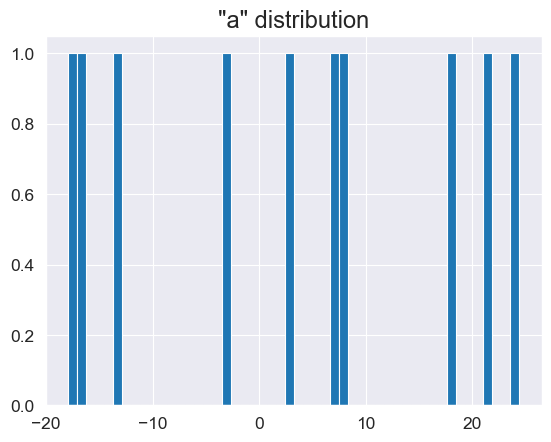

In [4]:
# # define hyperparameters
# n_points = 33300 # 2^15 + 1%; standard error 1/sqrt(N) of ~0.3%  
# popsize = 2**n_dim # 2^11 = 1 point per vertex
# maxiter = 1000*n_dim # 1000*n_dim = 11000 final; residuals < 1e-16;

# # test hyperparameters
n_points = 10 # testing number
popsize = 2**11 # testing number
maxiter = 11000 # testing number

def run_single_simulation(seed_val):
    '''Holds a single QUASAR task'''
    # result = [final_params, final_fitness]
    result = hdim.quasar(
        obj_func,
        bounds,
        kwargs={'evolution':True}, # enables boundary penalty + boolean C_sign
        popsize=popsize,
        maxiter=maxiter,
        tolerance=hbar/2,
        vectorized=True,
        polish=False,
        verbose=False,
        seed=seed_val
    )
    return result[0].reshape(1, n_dim), result[1]

# number of cores (-1 uses all available cores)
n_cores = -1 

########################### generate samples
# parallel execution
print(f'Running evolutionary optimization for {n_points} samples.')
results = Parallel(n_jobs=n_cores)(
  delayed(run_single_simulation)(i) for i in tqdm(range(n_points))
)


# results is a list of tuples: [(history, fitness)]
all_histories, all_fitnesses = zip(*results)

# stack and save histories
ensemble_srt = np.vstack(all_histories)
df_srt = pd.DataFrame(ensemble_srt, columns=zeta_order)
df_srt['fitness'] = all_fitnesses
df_srt.to_csv('spacetime_histories_test.csv', index=False) # save to a separate test file

# quick spatial analysis
df_srt['a'].hist(bins=50)
plt.title('"a" distribution')
plt.show()

## KDE

Occupancy: 0.254 ± 0.000979
Differential Entropy: 94.04% ± 1.4891%


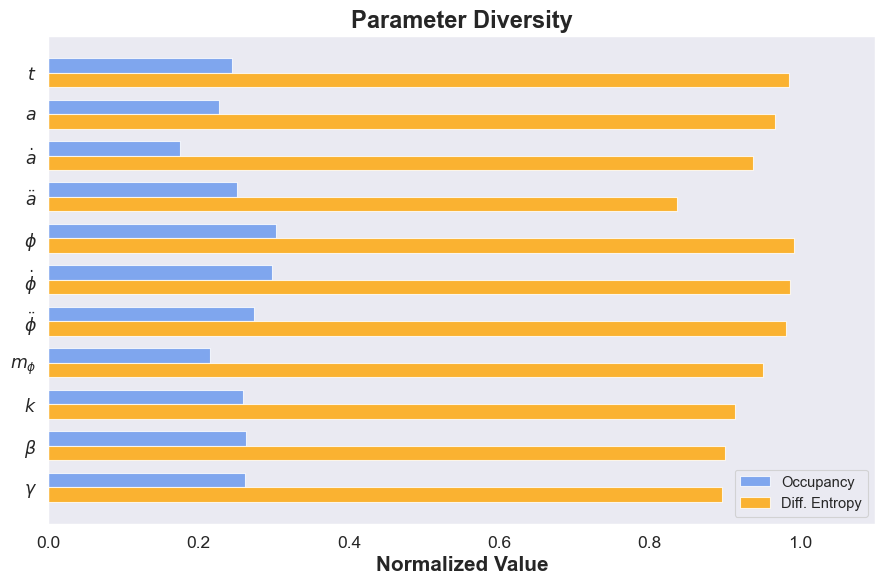

,efe_lhs,efe_rhs,kg_lhs,kg_rhs,acc_lhs,acc_rhs,rho_total,P_total,action,rho_kinetic,rho_potential,ricci_si,omega,nec,compactness,t_si,a_si,adot_si,adoubledot_si,phi_si,phidot_si,phidoubledot_si,mass_si,k,beta,gamma,H,H_km_s_Mpc,intensity,probability,tension,species,regime
0,7.797548e+02,7.797548e+02,2.542141e+38,2.542141e+38,7.797548e+02,7.797548e+02,1.253358e+29,-1.253358e+29,-6.858731e+57,3.427404e-28,1.253358e+29,1.041113e-13,-1.0,0.000000e+00,0.168252,2.265466e+08,6.227834e+06,-5.352309e+00,4.856183e+09,-8.862308e+07,-1.013541e-05,4.238827e+38,2.343991e-36,0.336504,0.599728,0.718804,-8.594175e-07,-2.652162e+13,-13.895476,-13.895476,1.421085e-14,Dark Energy,Canonical
1,5.349036e-12,5.349036e-12,-2.067764e+58,-2.067764e+58,5.349036e-12,5.349036e-12,8.597904e+14,-8.597904e+14,-8.979081e+13,1.195837e-102,8.597904e+14,7.141927e-28,-1.0,0.000000e+00,0.055593,1.293351e-42,4.322227e+13,4.447059e-21,2.311975e+02,7.474170e-27,7.956728e-43,-6.090131e+58,3.732298e-09,0.111186,0.339527,0.273436,1.028882e-34,3.175128e-15,-17.302266,-17.302266,3.552714e-15,Dark Energy,Canonical
2,-2.108883e+31,-2.108883e+31,1.791240e+35,1.791240e+35,4.217766e+31,4.217766e+31,-3.389765e+57,-3.389765e+57,-1.608922e+30,-3.389765e+57,1.703701e-07,1.407869e+15,1.0,-6.779530e+57,0.399256,2.390887e-06,5.833584e-08,1.076772e-09,2.460469e+24,-1.709664e-25,-1.883634e+38,-3.094027e-46,2.298005e-21,-0.798513,-0.017173,0.273156,1.845815e-02,5.696185e+17,-14.589993,-14.589993,1.421085e-14,Stiff,Hybrid
3,1.947682e+45,1.947682e+45,1.173398e+14,1.173398e+14,-3.895363e+45,-3.895363e+45,3.130654e+71,3.130654e+71,1.675083e+41,3.130654e+71,5.975396e-24,-1.300253e+29,1.0,6.261308e+71,0.091537,2.179103e+13,2.906528e-15,-5.339644e-46,-1.132198e+31,-9.153614e-21,-2.643139e+44,1.792530e-21,1.956629e-34,0.183074,0.805501,0.461005,-1.837121e-31,-5.669356e-12,-14.791287,-14.791287,3.552714e-15,Stiff,Canonical
4,-1.561267e+27,-1.561267e+27,1.446576e+19,1.446576e+19,3.122535e+27,3.122535e+27,-2.509542e+53,-2.509542e+53,-1.062682e+08,-2.509542e+53,1.361367e+08,1.042287e+11,1.0,-5.019083e+53,0.045988,3.475809e-29,2.301005e-06,8.602631e-23,7.184969e+21,-1.691630e+06,-3.497515e+35,1.466667e-39,4.608211e-45,-0.091975,-0.368762,0.554422,3.738641e-17,1.153744e+03,-15.156238,-15.156238,0.000000e+00,Stiff,Hybrid


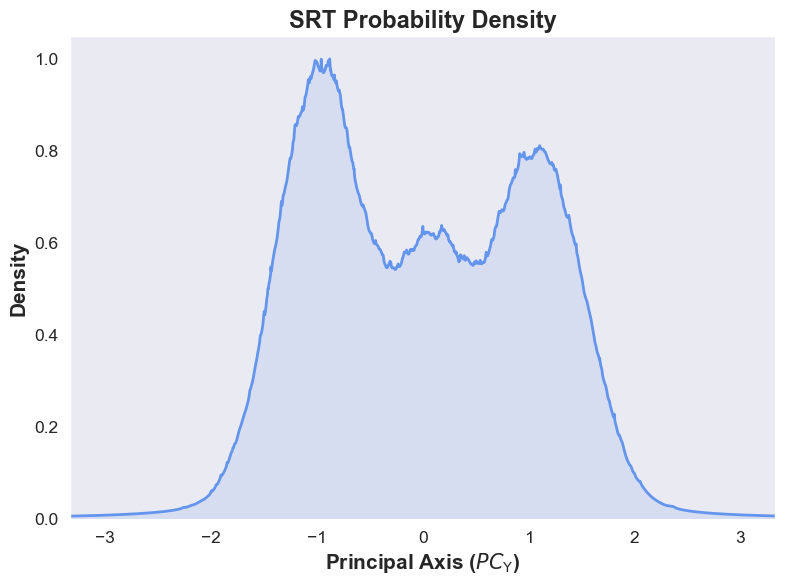

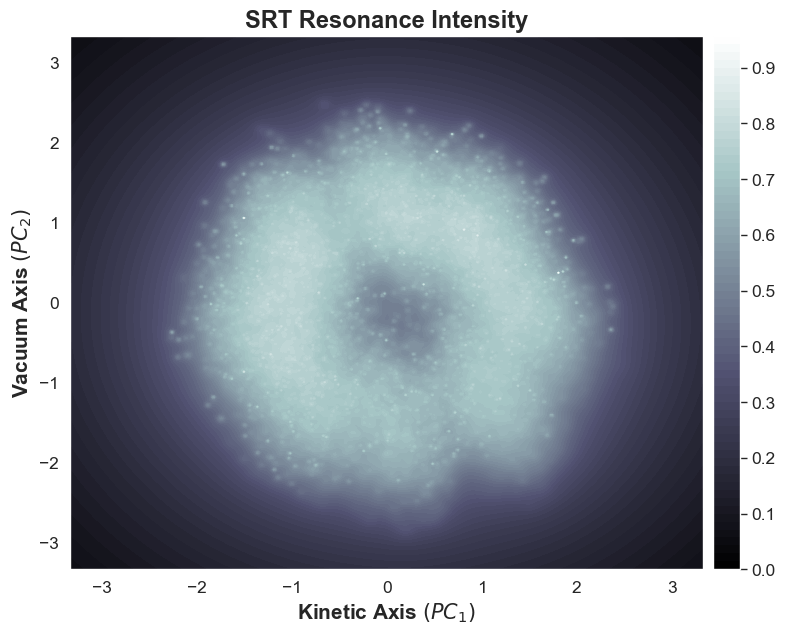

|              |          PC1 |
|:-------------|-------------:|
| t            |  0.0105583   |
| a            | -0.019225    |
| adot         | -0.010893    |
| adoubledot   |  0.656651    |
| phi          | -0.00971602  |
| phidot       |  0.0182418   |
| phidoubledot |  0.000192177 |
| mass_phi     | -0.0119693   |
| k            | -0.294698    |
| beta         | -0.638991    |
| gamma        |  0.269225    |
|              |          PC1 |          PC2 |
|:-------------|-------------:|-------------:|
| t            |  0.0118054   | -0.0346162   |
| a            | -0.0187061   |  0.187395    |
| adot         | -0.0112553   |  0.00326191  |
| adoubledot   |  0.647485    |  0.254492    |
| phi          | -0.0058321   |  0.00646712  |
| phidot       |  0.0173416   | -0.00958568  |
| phidoubledot | -0.000880808 | -0.000471025 |
| mass_phi     | -0.0181088   | -0.0703783   |
| k            | -0.319904    |  0.621669    |
| beta         | -0.647085    |  0.198401    |
| gamma        |  0.

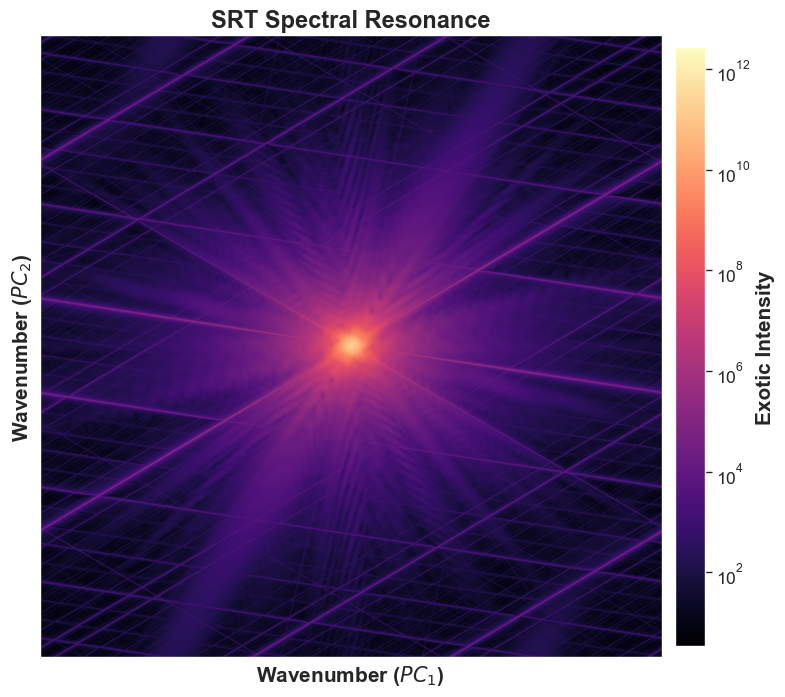

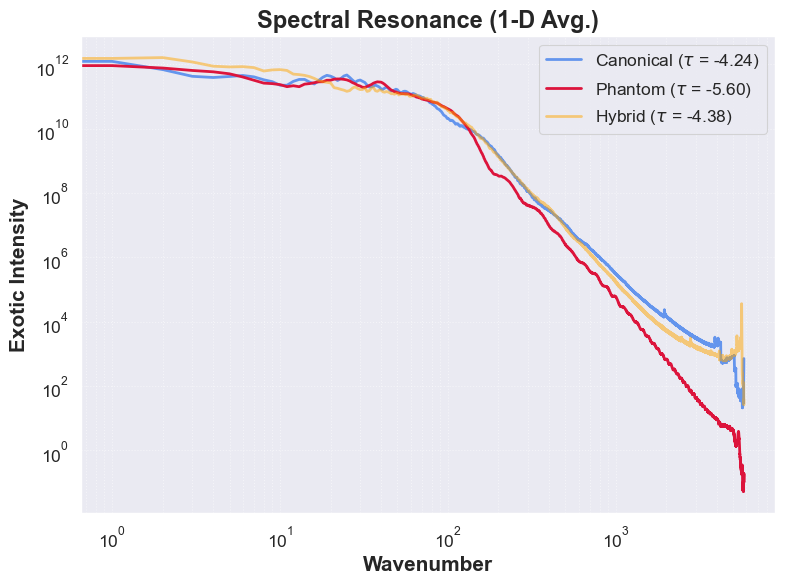

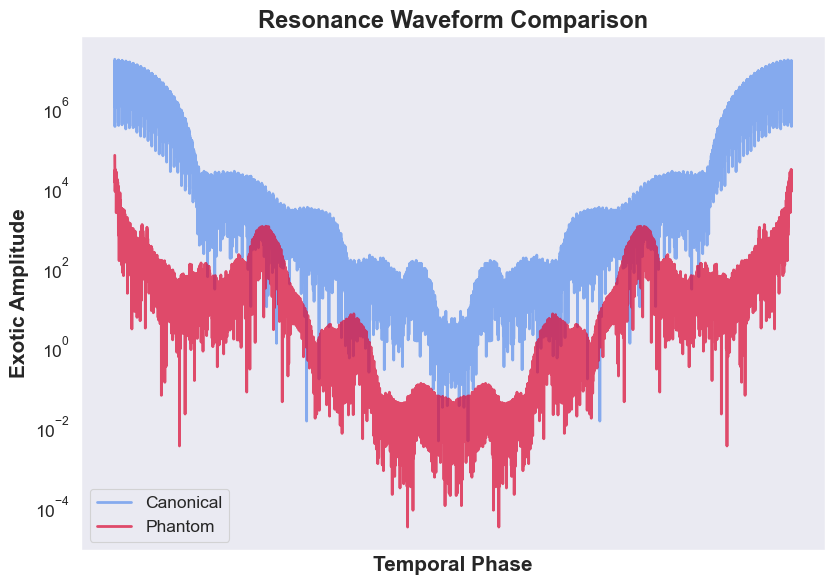

In [5]:
# KDE plot resolution
plot_points_1d = 2**17 if plot_resolution == 'high' else 2**10
plot_resolution_2d = 2**9 if plot_resolution == 'high' else 2**7

# misc parameters
sns.set_style('dark')
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.max_columns',None)

##### load and isotropize data #####

# load and clean
ensemble_exponents = pd.read_csv(history_path) 
# ensemble_exponents = pd.read_csv('spacetime_histories_test.csv') # for test data
ensemble_exponents = ensemble_exponents.drop_duplicates()
ensemble_exponents = ensemble_exponents[ensemble_exponents['fitness'] <= hbar/2].drop(['fitness'],axis=1)

# diversity
diversity_results = diversity_statistics(ensemble_exponents)
norm_entropies = diversity_results['efficiencies']

### isotropize ensemble
ensemble_isotropic, iso_params = hdim.isotropize(ensemble_exponents)
sigma_q_ensemble = quantum_bandwidth(ensemble_exponents, iso_params['W_zca_inv'], norm_entropies)

##### save topography architecture #####
np.savez_compressed('spacetime_data.npz', 
                    ensemble=ensemble_isotropic,
                    norm_entropies=norm_entropies,
                    iso_params=iso_params)
archive = np.load('spacetime_data.npz', allow_pickle=True)

ensemble_iso = archive['ensemble']
iso_params = archive['iso_params'].item()


#### topography assessment #####

# analyze coordinates
df_physics = analyze_coordinate(ensemble_exponents)
display(df_physics.head(5))

prob_1d, res_1d, ensemble_iso_1d = pca_kde() # principal axes
spectral_analysis(ensemble_exponents,metric='nec') # spectral decompositiion

## Analysis

\begin{table}[p]
\centering
\caption{Principal Axis Peak Probabilities}
\scriptsize
\setlength{\tabcolsep}{3pt}
\begin{tabular}{rc w{c}{1.2em} S[table-format=-1.1] S[table-format=1.1e2] || rc w{c}{1.2em} S[table-format=-1.1] S[table-format=1.1e2]}
\toprule
\textbf{x} & \textbf{Prob.} & \textbf{Reg.} & \textbf{$\omega$} & \textbf{NEC} & \textbf{x} & \textbf{Prob.} & \textbf{Reg.} & \textbf{$\omega$} & \textbf{NEC} \\
\midrule
-1.50 & 45.1\% & H. & 1.0 & 1.4e+58 & 0.24 & 61.8\% & C. & -1.0 & 0.0e+00 \\
-1.43 & 54.8\% & H. & 1.0 & 6.0e+55 & 0.29 & 59.5\% & C. & -1.0 & 0.0e+00 \\
-1.34 & 69.0\% & H. & 1.0 & 1.9e+51 & 0.31 & 58.1\% & C. & -1.0 & 0.0e+00 \\
-1.20 & 85.7\% & H. & 1.0 & 6.0e+47 & 0.36 & 57.4\% & C. & -1.0 & 0.0e+00 \\
-1.14 & 89.6\% & H. & 1.0 & 2.0e+45 & 0.37 & 57.0\% & C. & -1.0 & 0.0e+00 \\
-1.08 & 95.5\% & H. & 1.0 & 9.9e+42 & 0.39 & 57.2\% & C. & -1.0 & 0.0e+00 \\
-1.06 & 96.1\% & H. & 1.0 & 2.3e+42 & 0.42 & 56.8\% & C. & -1.0 & 0.0e+00 \\
-1.02 & 99.7\% & H. & 1.0 & 2.2e

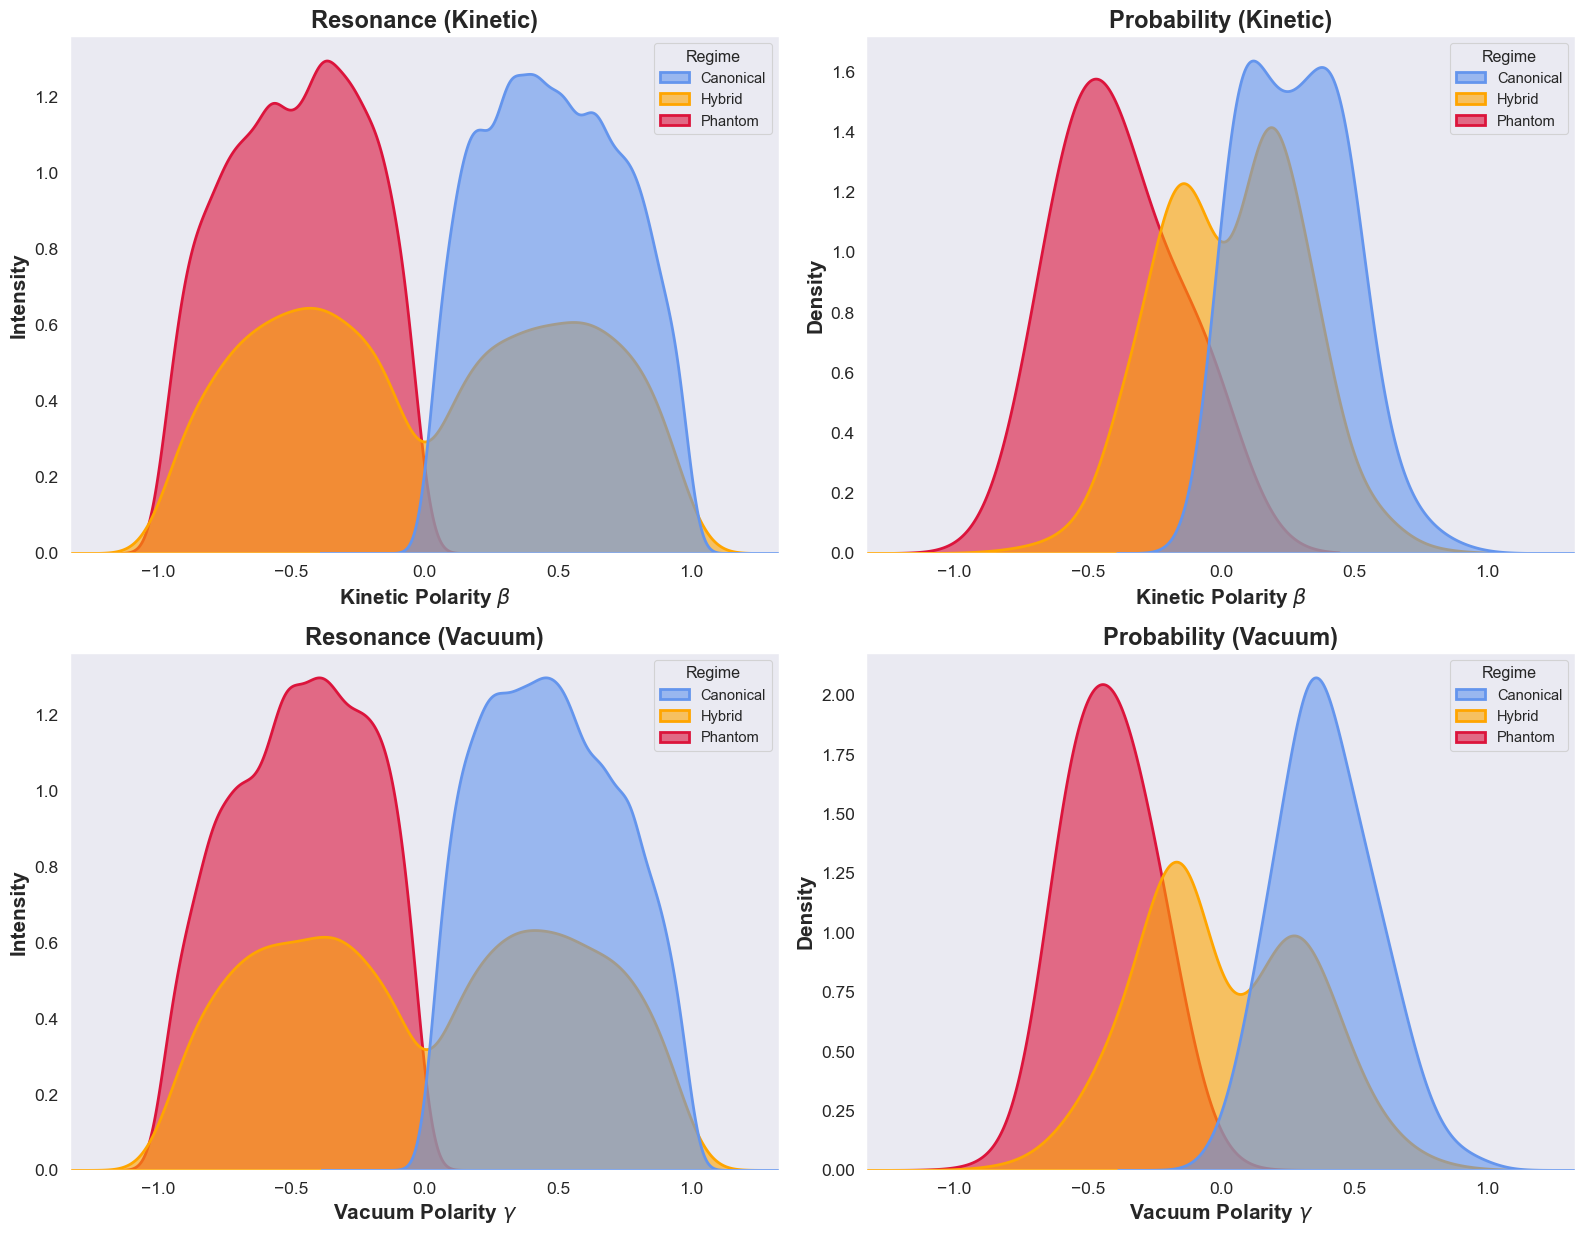


- Topography Analysis
Species                   | Resonance %  | Probability %
---------------------------------------------------------------------------
Dark Energy               | 34.8034     % | 68.0077     %
Stiff                     | 42.1555     % | 27.5981     %
Gravastar                 | 4.9259      % | 1.7291      %
Black Hole                | 7.1833      % | 0.9801      %
White Hole                | 5.7734      % | 0.8386      %
Hyperbolic Gravastar      | 4.4254      % | 0.5659      %
Wormhole                  | 0.6630      % | 0.2099      %
Superluminal              | 0.0240      % | 0.0301      %
Quintesscence             | 0.0178      % | 0.0180      %
Matter                    | 0.0027      % | 0.0149      %
Phantom Fluid             | 0.0221      % | 0.0074      %
Radiation                 | 0.0035      % | 0.0002      %

\begin{table}
\caption{Ensemble Physical Statistics}
\label{tab:physical_statistics}
\begin{tabular}{lr|rr|rr}
\toprule
 & Median & Mean & Stdev. &

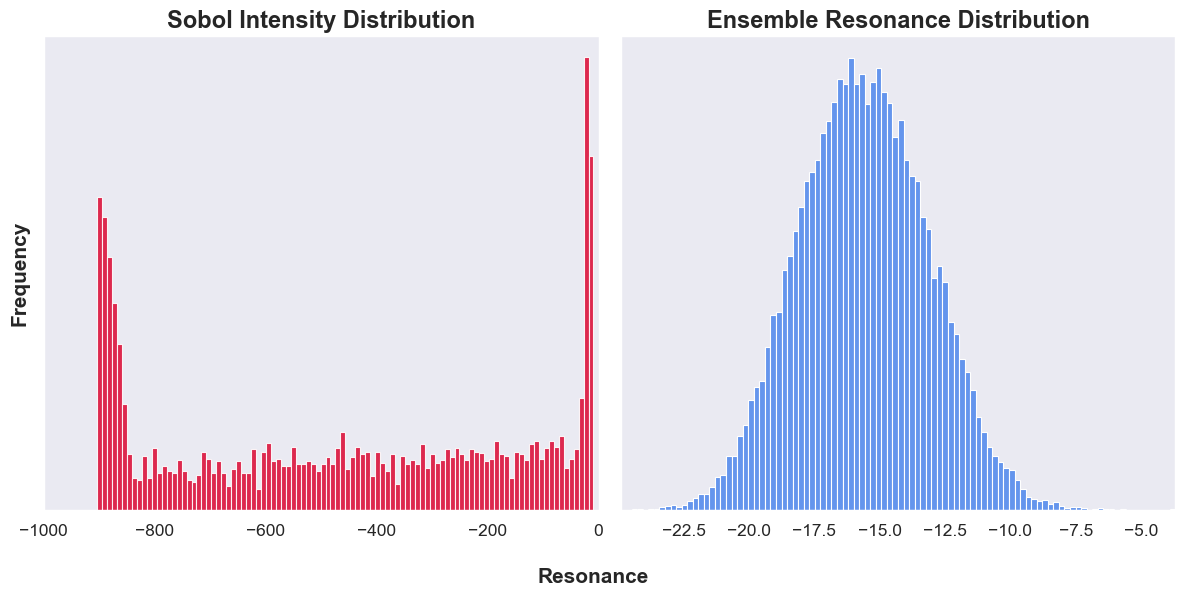

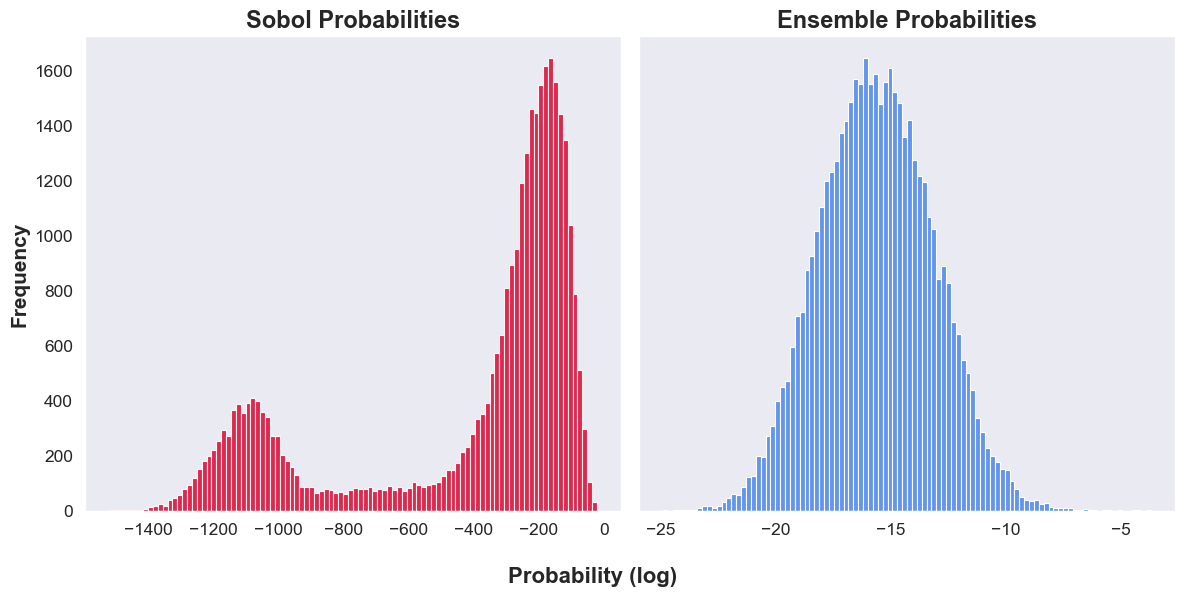

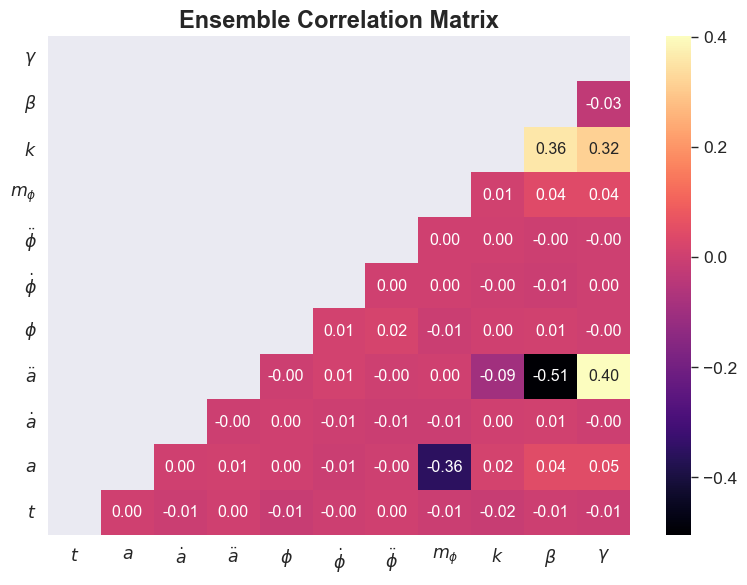

\begin{table}
\caption{Ensemble Covariance Matrix}
\label{tab:covariance}
\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & $t$ & $a$ & $\dot{a}$ & $\ddot{a}$ & $\phi$ & $\dot{\phi}$ & $\ddot{\phi}$ & $m_{\phi}$ & $k$ & $\beta$ & $\gamma$ \\
\midrule
$t$ & 223.9 & 0.6 & -3.8 & 2.3 & -6.7 & -2.6 & 5.9 & -1.2 & -0.1 & -0.0 & -0.1 \\
$a$ & 0.6 & 197.8 & 2.4 & 7.1 & 2.1 & -8.9 & -1.0 & -66.6 & 0.1 & 0.3 & 0.3 \\
$\dot{a}$ & -3.8 & 2.4 & 1862.0 & -9.3 & 5.9 & -15.8 & -26.8 & -3.4 & 0.1 & 0.1 & -0.1 \\
$\ddot{a}$ & 2.3 & 7.1 & -9.3 & 8496.8 & -8.4 & 57.6 & -9.0 & 4.6 & -4.5 & -24.5 & 19.4 \\
$\phi$ & -6.7 & 2.1 & 5.9 & -8.4 & 1150.9 & 27.6 & 60.4 & -4.0 & 0.0 & 0.1 & -0.0 \\
$\dot{\phi}$ & -2.6 & -8.9 & -15.8 & 57.6 & 27.6 & 4922.0 & 14.4 & 2.5 & -0.2 & -0.3 & 0.0 \\
$\ddot{\phi}$ & 5.9 & -1.0 & -26.8 & -9.0 & 60.4 & 14.4 & 9543.5 & 2.8 & 0.1 & -0.1 & -0.1 \\
$m_{\phi}$ & -1.2 & -66.6 & -3.4 & 4.6 & -4.0 & 2.5 & 2.8 & 176.9 & 0.0 & 0.3 & 0.3 \\
$k$ & -0.1 & 0.1 & 0.1 & -4.5 & 0.0 & -0.2 & 0.1 & 0.0 

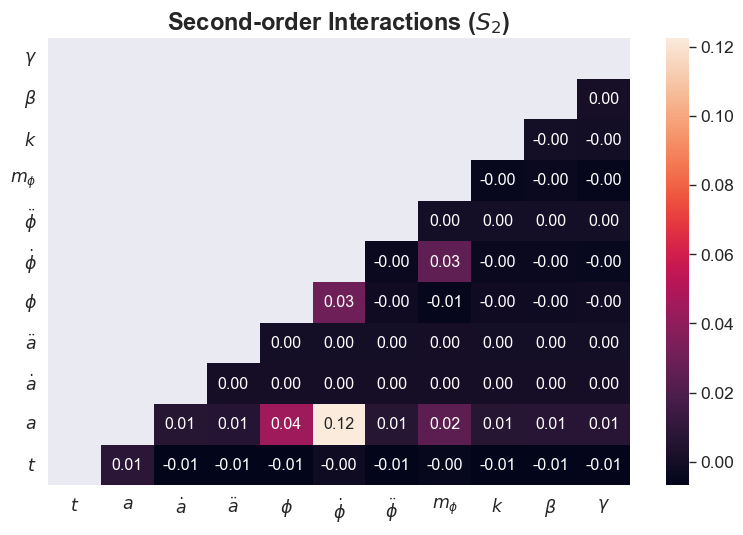

/var/folders/lg/qjz9rnn97jq8zysv08gn0bm80000gn/T/ipykernel_84919/4289335753.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s1_sorted = Si['S1'][sort_idx][-n_dim:]
/var/folders/lg/qjz9rnn97jq8zysv08gn0bm80000gn/T/ipykernel_84919/4289335753.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  st_sorted = Si['ST'][sort_idx][-n_dim:]
/var/folders/lg/qjz9rnn97jq8zysv08gn0bm80000gn/T/ipykernel_84919/4289335753.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by p

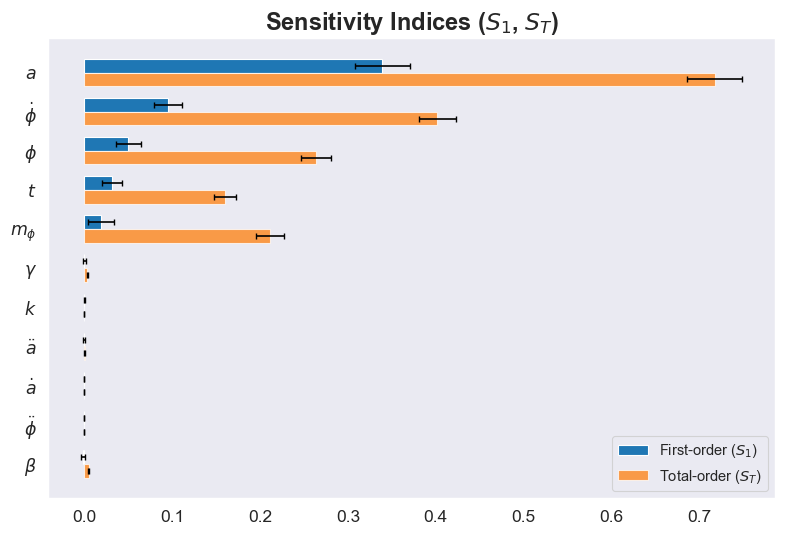

In [6]:
### analyze topography
peaks = peak_probabilities(prob_1d,ensemble_iso_1d)
physical_stats = physical_statistics(ensemble_exponents)
sobol_distributions() # compare resonance of a sobol sequence
covariance_analysis(ensemble_exponents)

# sensitivity analysis
n_sensitivity_samples = 2**13 if plot_resolution == 'high' else 2**12
bounds_iso_min = ensemble_isotropic.min(axis=0)
bounds_iso_max = ensemble_isotropic.max(axis=0)
bounds_iso = list(zip(bounds_iso_min, bounds_iso_max))
sens = hdim.sensitivity(
                    sensitivity_lorentzian_wrapper, kwargs={'ensemble': ensemble_isotropic}, 
                    bounds=bounds_iso, param_names=formatted_labels, n_samples=n_sensitivity_samples, 
                    calc_second_order=True, num_to_plot=n_dim, log_scale=False, verbose=False)
### plot heatmap of second order indices
s2_plot, ax = plt.subplots(1,1,figsize=(8, 5.5))

S2_filtered = sens[1]
mask_filtered = np.tril(np.ones_like(S2_filtered, dtype=bool))
sns.heatmap(data=S2_filtered, mask=mask_filtered, annot=True, fmt='.2f')
plt.title('Second-order Interactions ($S_2$)',fontweight='bold')
ax.invert_yaxis()
plt.yticks(rotation=0)
plt.yticks()
plt.tight_layout()
plt.savefig('plots/s2.png')
plt.show()



# sort by S1
Si = sens[0]
sort_idx = np.argsort(Si['S1'])
s1_sorted = Si['S1'][sort_idx][-n_dim:]
st_sorted = Si['ST'][sort_idx][-n_dim:]
s1_conf_sorted = Si['S1_conf'][sort_idx][-n_dim:]
st_conf_sorted = Si['ST_conf'][sort_idx][-n_dim:]
names_sorted = [np.array(formatted_labels)[i] for i in sort_idx][-n_dim:]
index = np.arange(len(names_sorted))

### plot 1: first-order (S1) and total-order (ST) indices
fig, ax = plt.subplots(1,1,figsize=(8, 5.5))

bar_width = 0.35
ax.barh(index + bar_width/2, s1_sorted, bar_width, xerr=s1_conf_sorted, 
           label='First-order ($S_1$)',
           alpha=1,
           capsize=2.5)
ax.set_yticks(index)
ax.set_yticklabels(names_sorted)

ax.barh(index - bar_width/2, st_sorted, bar_width,
           xerr=st_conf_sorted, 
           label='Total-order ($S_T$)',
           alpha=0.75, 
           capsize=2.5)

ax.set_title('Sensitivity Indices ($S_1$, $S_T$)',fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plots/sensitivity.png')
plt.show()

## Wormholes: Natural Probability & Tunneling

Asymmetric Deviation:
- Median: -160
- Superscript (+): 54
- Subscript (-): -134
Asymmetric Deviation:
- Median: -15
- Superscript (+): 3
- Subscript (-): -2
Repolarized median wormhole natural probability:
- Median: -160
- Superscript (+): 54
- Subscript (-): -134

Optimized median wormhole natural probability:
- Median: -15
- Superscript (+): 3
- Subscript (-): -2


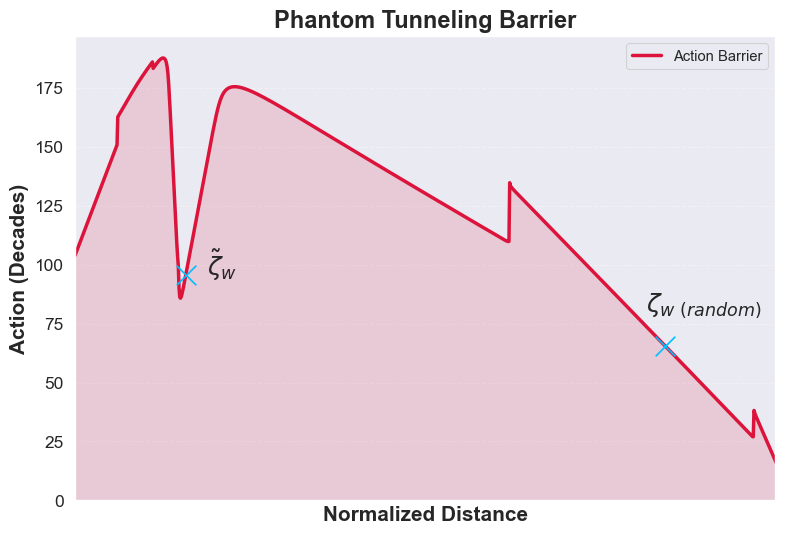

Tunneling Probability: e^-6.66e+04
Barrier Volume: 6.66e+04


In [20]:
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

################# median repolarized metrics #################
wormhole_species_raw = df_physics[df_physics['species']=='Wormhole']
wormhole_species = encode_zeta(wormhole_species_raw[zeta_order_si])
wormholes_canonical = repolarize_species('Wormhole', 1.0, 1.0)
print('Ensemble canonical-repolarized probability:')
asymmetric_deviation(wormholes_canonical['probability'].values)


################# identify optimal wormhole phase #################
opt_phase, opt_phase_err = find_natural_phase('Wormhole',n_iter=10)
wormholes_typical = repolarize_species('Wormhole', -0.15, 0.22) # using optimal phase (-0.15, 0.22)
print('Typical-optimized canonical-repolarized probability:')
asymmetric_deviation(wormholes_typical['probability'].values)


################# random tunneling comparison #################
random.seed(40) # 40 visually best
wormhole_median = np.array(np.median(wormhole_species,axis=0)) # median wormhole
wormhole_random = random.choice(wormhole_species) # random wormhole
results = tunneling_analysis(wormhole_median, wormhole_random)
print(f"Tunneling Probability: e^{results['probability']:.2e}")
print(f"Barrier Volume: {results['barrier_volume']:.2e}")

## Wormholes: Tunneling (Iterative)

Phase map:


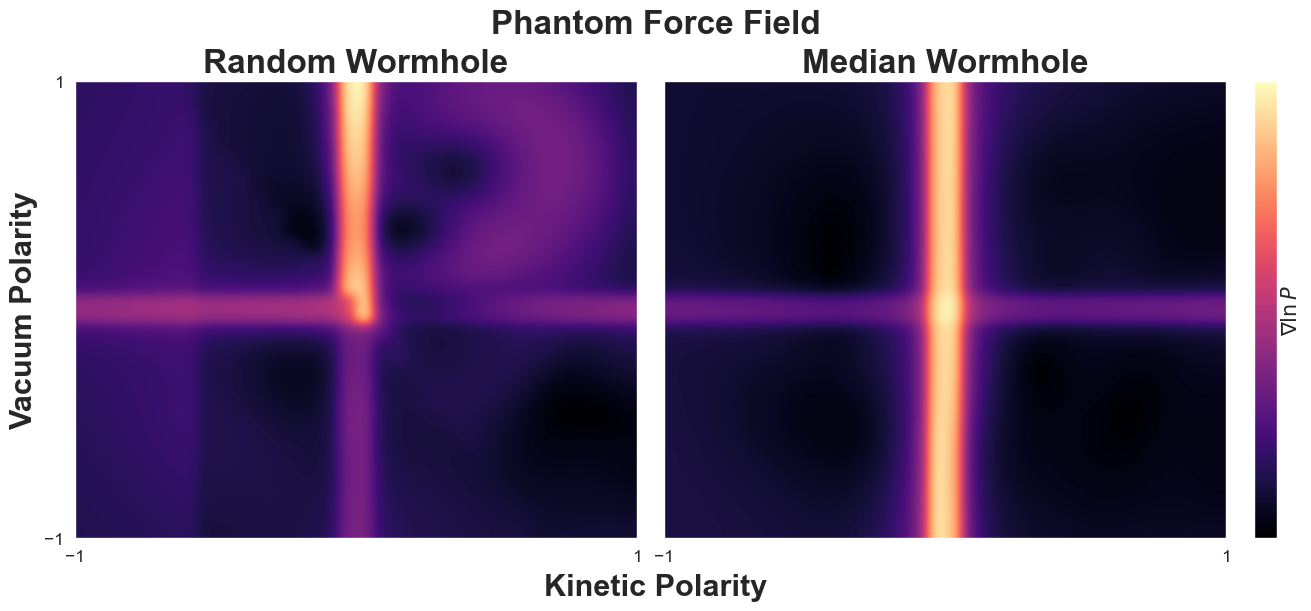

In [8]:
################# ensemble wormhole tunneling #################
# collect probabilities for each coordinate in ensemble
ensemble_tunnel_probabilities = []
print(f'Tunneling {len(wormhole_species)} ensemble wormholes.')
for i, zeta_w in enumerate(wormhole_species):
    # set destination (canonical phase)
    zeta_dest = zeta_w.copy()
    zeta_dest[9], zeta_dest[10] = 1, 1  # Set beta=1, gamma=1
    
    # run analysis
    stats = tunneling_analysis(zeta_w, zeta_dest, verbose=False)
    ensemble_tunnel_probabilities.append(stats['probability'])
ensemble_tunnel_probabilities = np.array(ensemble_tunnel_probabilities)


################ optimized typical-phase wormhole tunneling #################
bounds_w_natural = bounds
bounds_w_natural[-2], bounds_w_natural[-1] = (-0.150001, -0.14999), (0.21999, 0.220001)
opt_tunnel_vals = []
i = False
print('Generating natural-phase wormhole coordinates.')
while i == False:
    zeta_w_opt, fit = hdim.quasar(obj_func,bounds_w_natural,maxiter=11000,
                                         tolerance=hbar/2, vectorized=True, verbose=False) # optimized natural w coordinate
    coord_results = analyze_coordinate(zeta_w_opt)
    species = coord_results['species'][0]
    if (fit > hbar/2) or (species != 'Wormhole'):
        continue
    else:
        zeta_w_canonical_opt = zeta_w_opt.copy()
        zeta_w_canonical_opt[9], zeta_w_canonical_opt[10] = 1, 1
        tunnel_stats_temp = tunneling_analysis(zeta_w_opt, zeta_w_canonical_opt, verbose=False)
        opt_tunnel_vals += [tunnel_stats_temp['probability']]
    if len(opt_tunnel_vals) >= 209: # length of ensemble wormhole subset
        i = True
opt_tunnel_vals = np.array(opt_tunnel_vals)
opt_tunnel_vals = opt_tunnel_vals[opt_tunnel_vals!=-0.0]

# raw log-probability data
print('Ensemble wormhole tunneling:')
asymmetric_deviation(ensemble_tunnel_probabilities)

print('\nTypical-Optimized wormhole tunneling:')
asymmetric_deviation(opt_tunnel_vals)


###### plot wormhole force field phase map #####
print('Phase map:')
plot_force_fields(wormhole_random,wormhole_median,'Random Wormhole','Median Wormhole',res=32) 

## Wormholes: Tunneling Proportional to Stability

0.0 %
9.569377990430622 %
19.138755980861244 %
28.708133971291865 %
38.27751196172249 %
47.84688995215311 %
57.41626794258373 %
66.98564593301435 %
76.55502392344498 %
86.1244019138756 %
95.69377990430623 %
Probability of existence is negligible below: e^-141
Tunneling probability is negligible below: e^-1552
Expected value of tunneling into our universe at least once: 0.30

R^2 of Natural vs Tunneling Probabilities: 0.715
R^2 of Tunneling vs Natural Tension: 0.703
R^2 of Tunneling vs Natural Resonance: 0.052


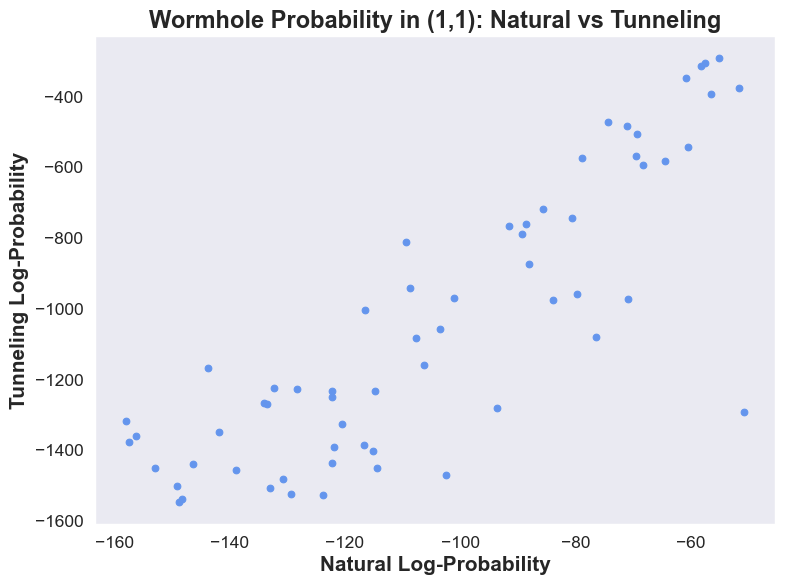

In [10]:
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
warnings.filterwarnings('ignore',category=DeprecationWarning)

# setup
wormhole_samples = df_physics[df_physics['species']=='Wormhole']
tunneling_probs = []
repol_probs = []
repol_tensions = []
repol_intensities = []
for i in range(len(wormhole_samples)):
    if i % (len(wormhole_samples) // 10) == 0:
        print(i/len(wormhole_samples)*100,'%')
    
    # source coordinate
    zeta_source = encode_zeta(wormhole_samples[zeta_order_si].iloc[i]).flatten()
    
    # destination coordinate (zeta_w^+)
    zeta_dest = zeta_source.copy()
    zeta_dest[9], zeta_dest[10] = 1.0, 1.0

    # natural metrics at destination
    results_repol = analyze_coordinate(zeta_dest)
    repol_proba = results_repol['probability'][0]
    proba_tension = results_repol['tension'][0]
    repol_intensity = results_repol['intensity'][0]
    repol_probs.append(repol_proba)
    repol_tensions.append(proba_tension)
    repol_intensities.append(repol_intensity)

    # integrates barrier between current phase and (1,1)
    tunnel_results = tunneling_analysis(zeta_source, zeta_dest, verbose=False)
    tunneling_probs.append(tunnel_results['probability'])

# convert results to arrays
tunneling_probs = np.array(tunneling_probs).reshape(-1,1)
repol_probs = np.array(repol_probs).reshape(-1,1)
repol_tensions = np.array(repol_tensions).reshape(-1,1)
repol_intensities = np.array(repol_intensities).reshape(-1,1)


##### minimum probability to exist at least once
max_time_quanta = 10**(bounds[0][1]-bounds[0][0])
min_natural_proba = -np.log(max_time_quanta)
min_tunnel_proba = -np.log(max_time_quanta)*n_dim
print(f'Probability of existence is negligible below: e^{min_natural_proba:.0f}')
print(f'Tunneling probability is negligible below: e^{min_tunnel_proba:.0f}')

# identify states with probability below 1 occurence in hubble age
outliers = (tunneling_probs < min_tunnel_proba) # (t_H / t_p)^-11
proportion_occurring = 1-np.sum(outliers)/len(wormhole_species)
print(f'Expected value of tunneling into our universe at least once: {proportion_occurring:.2f}')

### R^2 correlations
tunneling_probs_clean = tunneling_probs[~outliers].reshape(-1,1)
repol_probs_clean = repol_probs[~outliers].reshape(-1,1)
repol_tensions_clean = repol_tensions[~outliers].reshape(-1,1)
repol_intensities_clean = repol_intensities[~outliers].reshape(-1,1)

# tunneling vs probability
model = LinearRegression(fit_intercept=True)
model.fit(tunneling_probs_clean,repol_probs_clean)
r2 = model.score(tunneling_probs_clean,repol_probs_clean) # R^2
print(f'\nR^2 of Natural vs Tunneling Probabilities: {r2:.3f}')

# tunneling vs tension
model = LinearRegression(fit_intercept=True)
model.fit(tunneling_probs_clean,repol_tensions_clean)
r2 = model.score(tunneling_probs_clean,repol_tensions_clean) # R^2
print(f'R^2 of Tunneling vs Natural Tension: {r2:.3f}')

# tunneling vs resonance 
model = LinearRegression(fit_intercept=True)
model.fit(tunneling_probs_clean,repol_intensities_clean)
r2 = model.score(tunneling_probs_clean,repol_intensities_clean) # R^2
print(f'R^2 of Tunneling vs Natural Resonance: {r2:.3f}')

# Plot Tunneling Probability vs. Destination Static Probability
plt.figure(figsize=(8, 6))
plt.scatter(repol_probs_clean, tunneling_probs_clean, color='cornflowerblue')
plt.xlabel('Natural Log-Probability', fontweight='bold')
plt.ylabel('Tunneling Log-Probability', fontweight='bold')
plt.title('Wormhole Probability in (1,1): Natural vs Tunneling', fontweight='bold')
plt.tight_layout()
plt.savefig('wormhole_probability.png')
plt.show()


# Natural probability of exisence negligible below: e^-141
# Tunneling probability negligible below: e^-1552
# Expected value of tunneling into our universe at least once: 0.30
# R^2 of Natural vs Tunneling Probabilities: 0.715

## Symbolic Regression: Resonance Approximation

In [11]:
from gplearn.genetic import SymbolicRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# scale data
y = df_physics['probability'].copy()
X = encode_zeta(df_physics[zeta_order_si])
scaler = StandardScaler()
X = scaler.fit_transform(X)


# genetic parameters
est_gp = SymbolicRegressor(population_size=2**14,
                           generations=1000,
                           verbose=1,
                           parsimony_coefficient=0.002, 
                           random_state=5)

# fit to the ensemble
est_gp.fit(X, y)

# # print the resulting symbolic expression
print(est_gp._program)
y_pred = est_gp.predict(X)
print(f"R-squared: {r2_score(y, y_pred)}")

### result analytial function:
# sub(sub(0.606, mul(X10, X10)), sub(mul(X9, X9), add(sub(mul(sub(mul(0.606, X10), X8), X8), mul(X3, mul(mul(X3, X3), X3))), add(div(-0.345, 0.026), mul(X3, X3)))))
# R^2: 0.554 (parsimony 0.002 1000 gen) (lower R^2 than others, but highlights the simpler relationship; less overfit)

def test_analytic_approx(df_physics, zeta_order_si, scaler):
    '''
    Tests the symbolic function against KDE predictions.
    '''
    # scale data (1 unit = 1 stdev)
    X_raw = encode_zeta(df_physics[zeta_order_si])
    X_scaled = scaler.transform(X_raw)

    # map indices to variables
    a_dd  = X_scaled[:, 3]   # X3
    k     = X_scaled[:, 8]   # X8
    b  = X_scaled[:, 9]   # X9
    g = X_scaled[:, 10]  # X10
    
    # calculate analytical resonance
    ups_analytical = -12.7 - g**2 - b**2 - k**2 + 0.5*g*k - a_dd**4 + a_dd**2

    ups_kde = df_physics['intensity']
    
    # result metrics
    residual = ups_kde - ups_analytical
    correlation = np.corrcoef(ups_kde, ups_analytical)[0, 1]
    mae = mean_absolute_error(ups_kde,ups_analytical)

    print(f"Correlation: {correlation:.4f}")
    print(f"MAE: {mae:.4f}")

    return ups_analytical, residual

# compare analytical to KDE resonances
ups_vals, res = test_analytic_approx(df_physics, zeta_order_si, scaler)

plt.hist(res)
plt.title('Analytic vs Numerical Residuals')
plt.show()

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    27.17           289677       15          3.34369              N/A    179.15m
   1     6.72           15.496        3           2.7822              N/A    109.05m
   2    11.21          47.4704        7          2.20681              N/A    118.63m
   3    15.41          12.7536       11          1.88639              N/A    139.74m
   4    13.29          14.0803       11          1.74665              N/A    138.06m
   5    12.81          13.4924       11          1.70173              N/A    139.63m
   6    12.48          13.2274       17          1.58037              N/A    148.08m
   7    13.15          12.4042       17          1.58037              N/A    141.21m
   8    13.66          12.4338       19          1.54814              N/A  

KeyboardInterrupt: 

## Test Coordinates

In [24]:
# zeta_order = ['t','a','adot','adoubledot','phi','phidot','phidoubledot','mass_phi','k','beta','gamma']
### array of test coordinates

# random optimized coordinate
zeta_opt, fit = hdim.quasar(obj_func,bounds,maxiter=10,vectorized=True,verbose=False)
test_zeta = np.array([
    [-40.0, 3.5,   1.1,    6.7,    15.0,  10.0,   10.0,  -10.0,  1.0,   1.0, 1.0],   # black hole
    [-43.0, -34.8, 1.1,    61.7,   22.0,  110.0,  110.0, -7.7,  -1.0,  -1.0, 1.0],  # wormhole
    [-30.0, 4.0,   1.01,   56.7,   18.0,  0.0,    0.0,   -15.0,  0.9,   1.0, 1.0],   # gravastar
    [-20.0, 4.0,   1.01,   41.7,   12.0,  0.0,    0.0,   -12.0,  0.8,   1.0, 1.0],   # magnetar
    [17.0,  9.0,   1.001,  31.7,   5.0,   0.0,    0.0,   -30.0,  0.1,   1.0, 1.0],   # star (sun)
    [17.7,  28.0,  123.0,  155.1,  22.0,  116.0,  210.0, -50.0, -0.1,  -1.0, 1.0],  # phantom rip
    [-40.0, 3.5,   61.0,   131.7,  15.0,  110.0,  180.0, -10.0,  -1.0,   1.0, 1.0],   # white hole
    [-15.0, -10.0, 1.0,    51.7,   -10.0, 0.0,    0.0,   -25.0,  0.0,   1.0, 1.0],   # atom (H)
    [17.0,  6.8,   1.001,  21.7,   2.0,   0.0,    0.0,   -40.0,  0.01,  1.0, 1.0],    # planet
    zeta_opt
])

# iterate through test coordinates
add_em_energy = 1e113
for i in range(len(test_zeta)):
    results = analyze_coordinate(test_zeta[[i]])

    # raw probability
    print(f'Probability: {results['species'][0]} ({results['regime'][0]}): e^{results['probability'][0]:.1f}')

    # apply electromagnetic energy
    results = analyze_coordinate(test_zeta[[i]],rho_em=add_em_energy)
    print(f'With EM energy: {results['species'][0]} ({results['regime'][0]}): e^{results['probability'][0]:.1f}')
    print()

Probability: Dark Energy (Canonical): e^-104.1
With EM energy: Dark Energy (Canonical): e^-105.4

Probability: Stiff (Hybrid): e^-496.3
With EM energy: Stiff (Hybrid): e^-118.1

Probability: Dark Energy (Canonical): e^-300.9
With EM energy: Dark Energy (Canonical): e^-302.1

Probability: Dark Energy (Canonical): e^-315.0
With EM energy: Dark Energy (Canonical): e^-316.2

Probability: Dark Energy (Canonical): e^-382.2
With EM energy: Dark Energy (Canonical): e^-383.6

Probability: White Hole (Hybrid): e^-371.2
With EM energy: White Hole (Hybrid): e^-371.3

Probability: White Hole (Canonical): e^-406.2
With EM energy: White Hole (Canonical): e^-406.4

Probability: Dark Energy (Canonical): e^-999.7
With EM energy: Dark Energy (Canonical): e^-374.2

Probability: Dark Energy (Canonical): e^-451.8
With EM energy: Dark Energy (Canonical): e^-454.0

Probability: Dark Energy (Canonical): e^-18.0
With EM energy: Dark Energy (Canonical): e^-19.4

